Purpose
-------
    Create figures for Marion's paper
        

## imports

In [106]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe

# statistics package
import skill_metrics as sm

# fit b-values
from scipy.optimize import curve_fit


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


moddir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/"
obsdir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/observations"
os.chdir(obsdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


In [107]:
import warnings
warnings.filterwarnings('ignore')

# start up a dask client

In [3]:
import dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=14, threads_per_worker=1, memory_limit="8GB")
client  = Client(cluster)
client  # shows dashboard link



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 104.31 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38871,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40109,Total threads: 1
Dashboard: /proxy/45203/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:40237,


## load observations

In [108]:
%%time

os.chdir(obsdir)

bottle_data = xr.open_dataset("sots_monthly_climatology.nc").squeeze()
pco2_data = xr.open_dataset("sots_sofs_pco2_monthly_climatology.nc").squeeze()
chl_data = xr.open_dataset("sots_chl_30m_monthly_climatology.nc").squeeze()
zoo_data = xr.open_dataset("maredat_zoo.nc").squeeze()
bac_data = pd.read_csv("TAN1810_Bacteria_Salp_biomass_converted_mmolC_m3.csv")

### cut out depths > 500 metres
bottle_data = bottle_data.sel(depth=slice(0,500))
zoo_data = zoo_data.sel(DEPTH=slice(0,500))

### Bacterial data
bac_data = bac_data[['Depth water [m]','Bact C [mmol C/m**3] (20 fg C/cell)']]
bac_data = bac_data.sort_values(by='Depth water [m]', ascending=True)
bac_data = bac_data.rename(columns={'Depth water [m]':'depth', 'Bact C [mmol C/m**3] (20 fg C/cell)':'bac'})
bac_data_mean = bac_data.groupby('depth', as_index=False).mean()
bac_data_std = bac_data.groupby('depth', as_index=False).std()
bac_data_mean
bac_data_smooth = pd.DataFrame({
    'depth':bac_data_mean['depth'].values, 
    'mean':bac_data_mean['bac'].values, 
    'std':bac_data_std['bac'].values
})
bac_data

### Argo data
argo_data = xr.open_dataset("ARGO_SOTS.nc").squeeze()
argo_data



CPU times: user 277 ms, sys: 83 ms, total: 360 ms
Wall time: 584 ms


<xarray.Dataset> Size: 444kB
Dimensions:   (pressure: 1501, month: 12)
Coordinates:
  * pressure  (pressure) int64 12kB 0 1 2 3 4 5 ... 1496 1497 1498 1499 1500
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    POC       (pressure, month) float64 144kB ...
    CHL       (pressure, month) float64 144kB ...
    NO3       (pressure, month) float64 144kB ...

In [109]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

bac_xr = (
    bac_data_smooth
    .set_index("depth")
    .to_xarray()
)

bac_data_obsgrid = bac_xr.interp(depth=target_depth)
bac_data_obsgrid


CPU times: user 13 ms, sys: 1.83 ms, total: 14.8 ms
Wall time: 14.2 ms


<xarray.Dataset> Size: 624B
Dimensions:  (depth: 26)
Coordinates:
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Data variables:
    mean     (depth) float64 208B nan 2.496 2.26 1.984 1.192 ... nan nan nan nan
    std      (depth) float64 208B nan 1.018 0.9538 0.396 ... nan nan nan nan

In [110]:
%%time

argo_data_obsgrid = argo_data.interp(pressure=target_depth)
argo_data_obsgrid = argo_data_obsgrid.where(argo_data_obsgrid.depth > 10.0, other=np.nan)



CPU times: user 25.3 ms, sys: 0 ns, total: 25.3 ms
Wall time: 22.6 ms


### Load the NPP observations

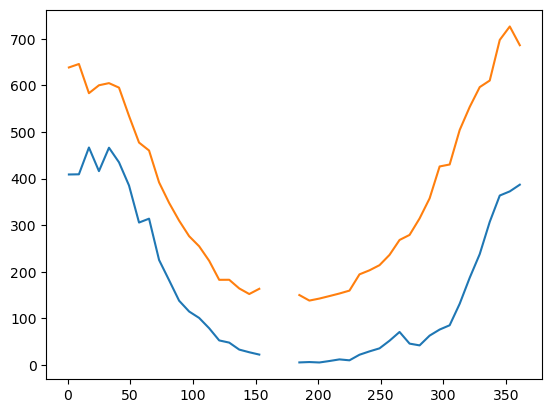

In [111]:
import h5py

f = h5py.File("VIIRS_CbPM_NPP_Data_SOTS.mat", "r")
cbpm = f["VIIRS_CbPM_NPP"][:]
Tlat1 = f["TLat"][:]
Tlon1 = f["TLon"][:]
days1 = f["days"][:]
years1 = f["years"][:]

f = h5py.File("VIIRS_VGPM_NPP_Data_SOTS.mat", "r")
vgpm = f["VIIRS_VGPM_NPP"][:]
Tlat2 = f["TLat"][:]
Tlon2 = f["TLon"][:]
days2 = f["days"][:]
years2 = f["years"][:]

cbpm_xr = xr.DataArray(
    cbpm,
    dims=("x", "y", "day", "year"),
    coords={
        "lon": (("x", "y"), Tlon1),
        "lat": (("x", "y"), Tlat1),
        "day": days1.squeeze(),
        "year": years1.squeeze(),
    },
    name="NPP (CbPM)",
    attrs={
        "long_name": "VIIRS CbPM Net Primary Production"
    }
)

vgpm_xr = xr.DataArray(
    vgpm,
    dims=("x", "y", "day", "year"),
    coords={
        "lon": (("x", "y"), Tlon2),
        "lat": (("x", "y"), Tlat2),
        "day": days2.squeeze(),
        "year": years2.squeeze(),
    },
    name="NPP (VGPM)",
    attrs={
        "long_name": "VIIRS VGPM Net Primary Production"
    }
)

plt.figure()
plt.plot(cbpm_xr.coords['day'], cbpm_xr.mean(dim=['x', 'y', 'year']))
plt.plot(vgpm_xr.coords['day'], vgpm_xr.mean(dim=['x', 'y', 'year']))



In [112]:
print("put all the observations into a dictionary for iteration")
obsdata = {
    'dpco2': pco2_data['delta_pco2'],
    'fgco2': pco2_data['co2_flux_mol_m2_y1'],
    'nh4': bottle_data['ammonia'].sel(depth=slice(0,100)).mean(dim='depth'), 
    #'no3': bottle_data['nitrate'].sel(depth=slice(0,100)).mean(dim='depth'), 
    'no3': argo_data_obsgrid['NO3'].sel(depth=slice(0,100)).mean(dim='depth'), 
    'sil': bottle_data['silicate'].sel(depth=slice(0,100)).mean(dim='depth'), 
    'dfe': bottle_data['dFe'].sel(depth=slice(0,100)).mean(dim='depth'), 
    #'poc': bottle_data['POC'].sel(depth=slice(0,100)).mean(dim='depth')*0.5/3.0, 
    'poc': argo_data_obsgrid['POC'].sel(depth=slice(0,100)).mean(dim='depth')*0.5/12/3.0, 
    'bac': bac_data_obsgrid['mean'], 
    'micro': zoo_data['micro_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    'meso': zoo_data['meso_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    #'chl_bottle': bottle_data['chlorophyll_total_mv'].sel(depth=slice(0,100)).mean(dim='depth'),
    'chl_bottle': argo_data_obsgrid['CHL'].sel(depth=slice(0,100)).mean(dim='depth'),
    'chl_mooring': chl_data['chlorophyll'],
    'npp_CbPM': cbpm_xr.mean(dim=['x', 'y', 'year']),
    'npp_VGPM': vgpm_xr.mean(dim=['x', 'y', 'year']),
    }


put all the observations into a dictionary for iteration


## Now, load the model output

In [113]:
%%time

vars2d = ['pco2', 'dic_stf', 'mlotst', 'npp2d']
vars3d = ['thetao', 'so', 
          'phy', 'dia', 'pchl', 'dchl', 
          'o2', 'no3', 'nh4', 'fe', 'sil',
          'sdet', 'ldet', 'sdet_vmove', 'ldet_vmove',
          'zoo', 'mes', 'lbac', 'obac', 'sbac',
          'lbacpco2', 'obacpco2', 'sbacpco2',
          'lbacresp', 'obacresp', 'sbacresp',
          'ldoc', 'odoc', 'sdoc',
          'ldon', 'odon', 'sdon']

exps = ['pa0p0', 'pa1p0_la0p0', 'pa1p0_la0p05', 'pa1p0_la0p10', 'pa1p0_la0p15', 'pa1p0_la0p20', 
        'pa1p0_la0p25', 'pa1p0_la0p30', 'pa1p0_la0p35', 'pa1p0_la0p40', 'pa1p0_la0p45', 
        'pa1p0_la0p50', 'pa1p0_la0p55', 'pa1p0_la0p60', 'pa1p0_la0p65', 'pa1p0_la0p70', 
        'pa1p0_la0p75', 'pa1p0_la0p80', 'pa1p0_la0p85', 'pa1p0_la0p90', 'pa1p0_la0p95'] 
        

mod = {}
for vv in vars2d:
    for exp in exps:
        mod[vv + "_" + exp] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull_4MF_highNPP_%s/output009/access-om3.mom6.2d.%s.1day.mean.1909.nc'%(exp,vv), decode_timedelta=True)[vv].isel(yh=1,xh=1)
for vv in vars3d:
    for exp in exps:
        mod[vv + "_" + exp] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull_4MF_highNPP_%s/output009/access-om3.mom6.3d.%s.1day.mean.1909.nc'%(exp,vv), decode_timedelta=True)[vv].isel(yh=1,xh=1)
    


CPU times: user 25.1 s, sys: 8.62 s, total: 33.8 s
Wall time: 50.2 s


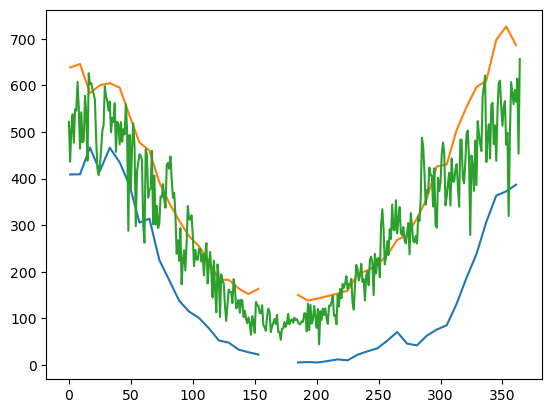

In [114]:
plt.figure()
plt.plot(cbpm_xr.coords['day'], cbpm_xr.mean(dim=['x', 'y', 'year']))
plt.plot(vgpm_xr.coords['day'], vgpm_xr.mean(dim=['x', 'y', 'year']))
plt.plot(mod['npp2d_pa0p0']*1e3*12*86400)

### Calculate additional metrics

In [115]:
%%time

for xx in exps:
    mod["RQ_%s"%(xx)] = (mod["lbacpco2_%s"%(xx)] + mod["obacpco2_%s"%(xx)]) / (mod["lbacresp_%s"%(xx)] + mod["obacresp_%s"%(xx)])
    mod["lbacRQ_%s"%(xx)] = (mod["lbacpco2_%s"%(xx)]) / (mod["lbacresp_%s"%(xx)])
    mod["lbacRQ_%s"%(xx)] = (mod["lbacpco2_%s"%(xx)] ) / (mod["lbacresp_%s"%(xx)])
    mod["obacRQ_%s"%(xx)] = (mod["obacpco2_%s"%(xx)] ) / (mod["obacresp_%s"%(xx)])
    mod["exp_sdet_%s"%(xx)] = (mod["sdet_%s"%(xx)] *  mod["sdet_vmove_%s"%(xx)])
    mod["exp_ldet_%s"%(xx)] = (mod["ldet_%s"%(xx)] *  mod["ldet_vmove_%s"%(xx)])
    mod["doc_%s"%(xx)] = (mod["ldoc_%s"%(xx)] + mod["odoc_%s"%(xx)] + mod["sdoc_%s"%(xx)])
    mod["n2c_%s"%(xx)] = (mod["ldon_%s"%(xx)] + mod["odon_%s"%(xx)] + mod["odon_%s"%(xx)]) / (mod["doc_%s"%(xx)])
    mod["bac_%s"%(xx)] = (mod["lbac_%s"%(xx)] + mod["obac_%s"%(xx)] + mod["sbac_%s"%(xx)])
    


CPU times: user 1.77 s, sys: 387 ms, total: 2.15 s
Wall time: 1.9 s


### Create figure of all output from best run

In [116]:
%%time

import cftime

time = mod['mlotst_pa0p0'].coords['time']
time = xr.DataArray(cftime.date2num(time.values, units="days since 1909-01-01", calendar="noleap"),
    dims=time.dims,
    coords=time.coords,
    name="time_days"
)

deps = mod['no3_pa0p0'].coords['zl']
deps

CPU times: user 1.46 ms, sys: 538 μs, total: 2 ms
Wall time: 1.99 ms


<xarray.DataArray 'zl' (zl: 75)> Size: 600B
array([5.412807e-01, 1.680735e+00, 2.939953e+00, 4.331522e+00, 5.869350e+00,
       7.568810e+00, 9.446885e+00, 1.152234e+01, 1.381593e+01, 1.635055e+01,
       1.915154e+01, 2.224687e+01, 2.566746e+01, 2.944746e+01, 3.362460e+01,
       3.824057e+01, 4.334140e+01, 4.897796e+01, 5.520640e+01, 6.208873e+01,
       6.969342e+01, 7.809601e+01, 8.737989e+01, 9.763700e+01, 1.089687e+02,
       1.214869e+02, 1.353144e+02, 1.505868e+02, 1.674530e+02, 1.860765e+02,
       2.066365e+02, 2.293296e+02, 2.543701e+02, 2.819920e+02, 3.124492e+02,
       3.460166e+02, 3.829906e+02, 4.236883e+02, 4.684475e+02, 5.176242e+02,
       5.715899e+02, 6.307275e+02, 6.954248e+02, 7.660668e+02, 8.430255e+02,
       9.266482e+02, 1.017244e+03, 1.115068e+03, 1.220310e+03, 1.333076e+03,
       1.453384e+03, 1.581154e+03, 1.716205e+03, 1.858264e+03, 2.006975e+03,
       2.161913e+03, 2.322601e+03, 2.488533e+03, 2.659189e+03, 2.834054e+03,
       3.012631e+03, 3.194453e+03, 3.379089e+03, 3.566145e+03, 3.755274e+03,
       3.946166e+03, 4.138552e+03, 4.332197e+03, 4.526903e+03, 4.722497e+03,
       4.918835e+03, 5.115794e+03, 5.313270e+03, 5.511177e+03, 5.805115e+03])
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * zl       (zl) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.805e+03
Attributes:
    units:      meter
    long_name:  Layer pseudo-depth, -z*
    axis:       Z
    positive:   down

CPU times: user 4.43 s, sys: 373 ms, total: 4.8 s
Wall time: 4.19 s


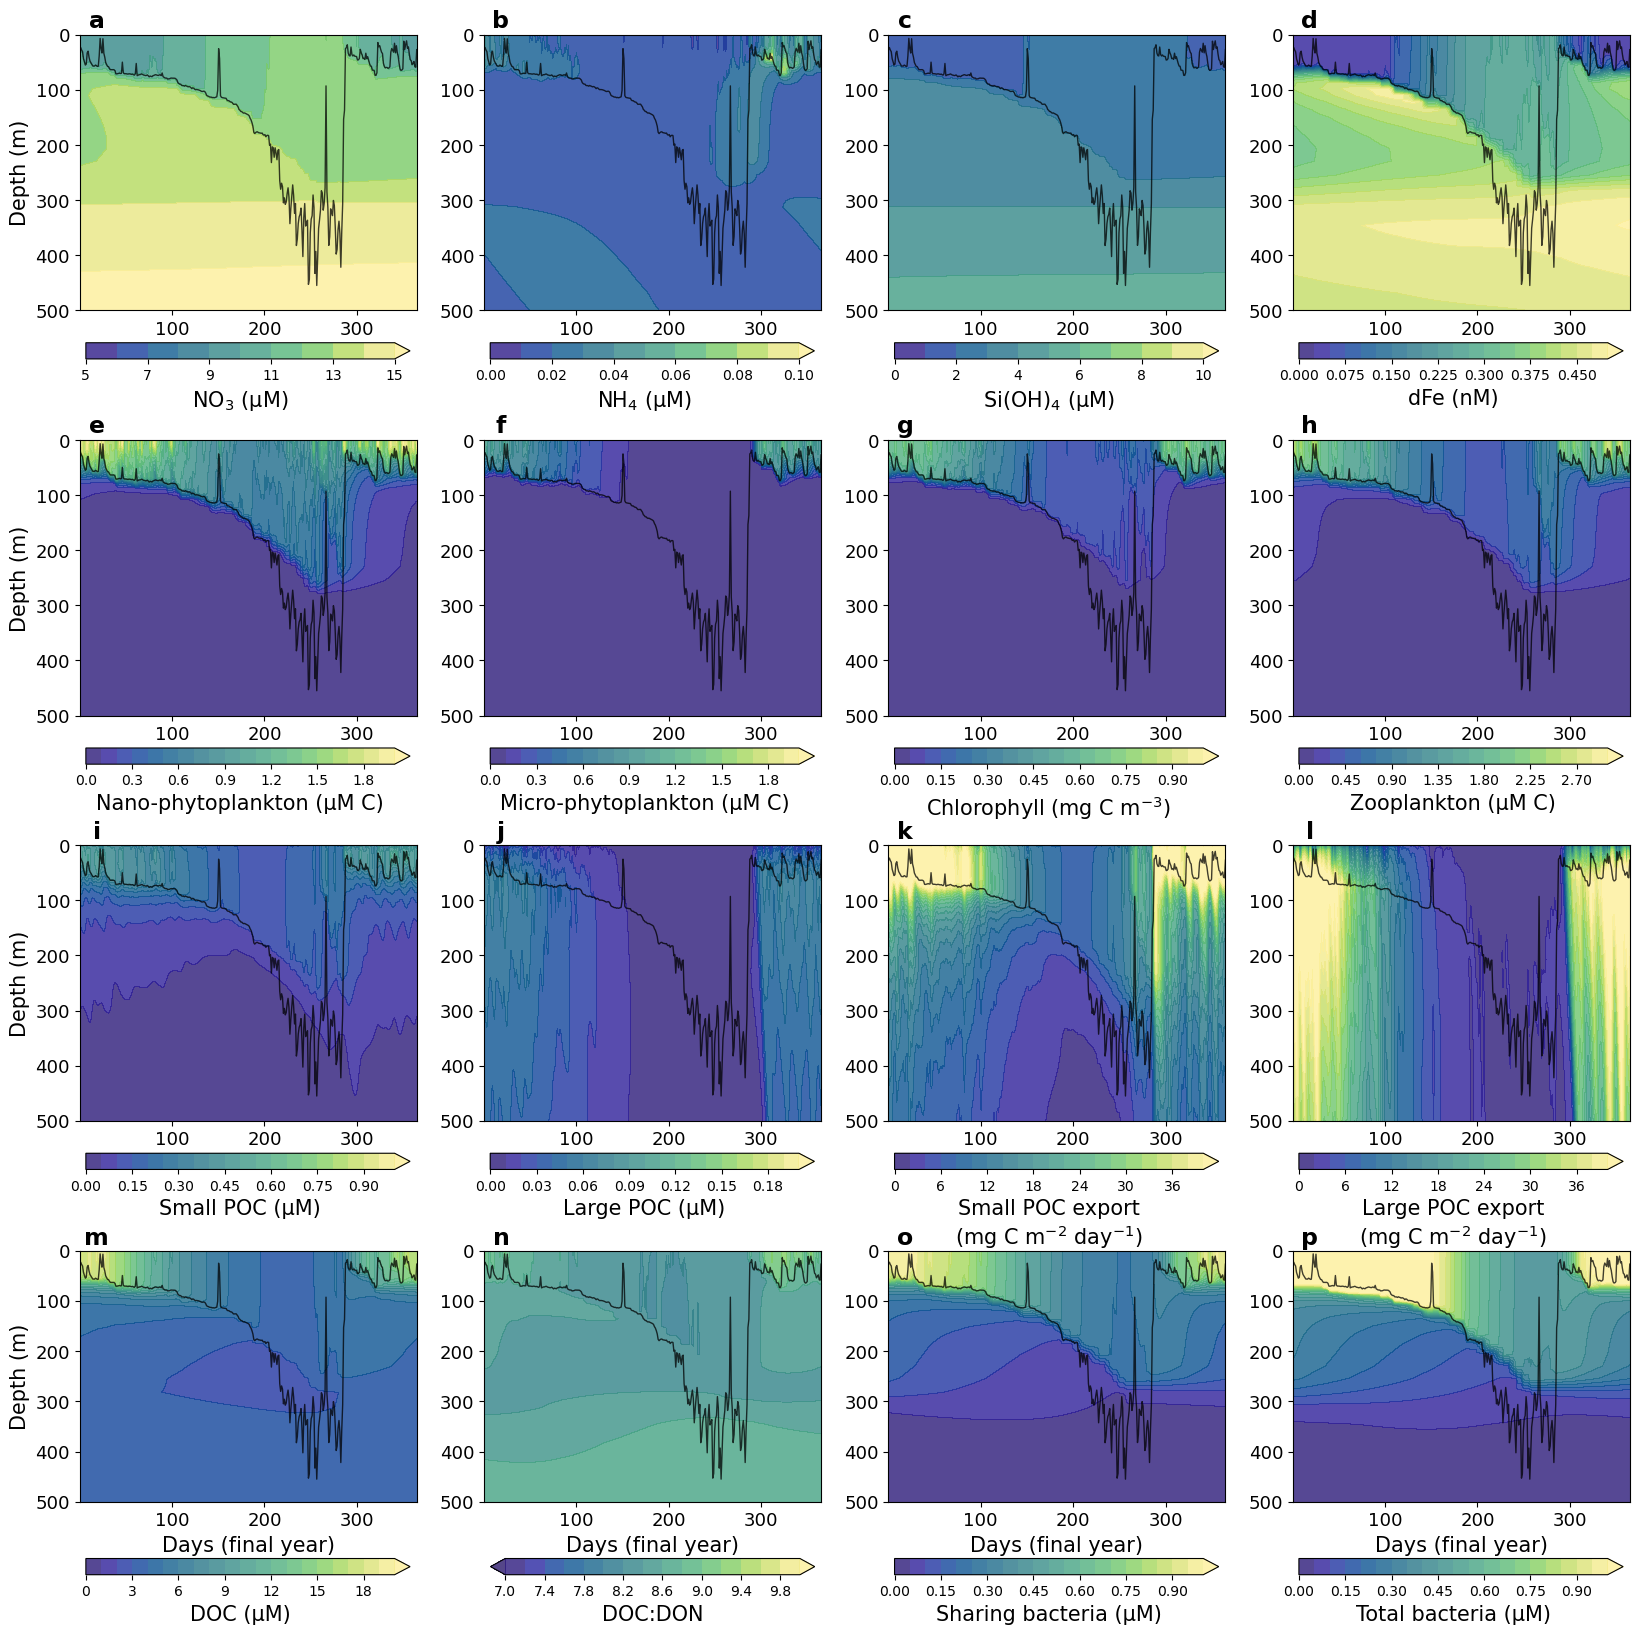

In [117]:
%%time

exp = "pa1p0_la0p50"

fstic = 13
fslab = 15

# for contour plots
colmap = lighten(cmo.haline, 0.8)
levs_no3 = np.arange(5,16,1)
levs_nh4 = np.arange(0,11,1)*0.01
levs_sil = np.arange(0,11,1)
levs_dfe = np.arange(0,21,1)*0.025
levs_phy = np.arange(0,21,1)*0.1
levs_dia = np.arange(0,21,1)*0.1
levs_chl = np.arange(0,21,1)*0.05
levs_zoo = np.arange(0,21,1)*0.15
levs_sdet = np.arange(0,21,1)*0.05
levs_ldet = np.arange(0,21,1)*0.01
levs_exp = np.arange(0,21,1)*2
levs_doc = np.arange(0,21,1)
levs_lbac = np.arange(0,21,1)*0.05
levs_obac = np.arange(0,21,1)*0.05
levs_rq = np.arange(0.3,1.2,0.05)
levs_c2n = np.arange(7,10.1,0.2)

labs = ['NO$_3$ (µM)', 'NH$_4$ (µM)', 'Si(OH)$_4$ (µM)', 'dFe (nM)',
        'Nano-phytoplankton (µM C)', 'Micro-phytoplankton (µM C)', 'Chlorophyll (mg C m$^{-3}$)', 'Zooplankton (µM C)',
        'Small POC (µM)', 'Large POC (µM)', 'Small POC export\n(mg C m$^{-2}$ day$^{-1}$)', 'Large POC export\n(mg C m$^{-2}$ day$^{-1}$)',
        'DOC (µM)', 'DOC:DON', 'Sharing bacteria (µM)', 'Total bacteria (µM)']

# for MLD
col = 'k'; lwid = 1.0; alf = 0.75; zord = 3

fig = plt.figure(figsize=(20,20))
gs = GridSpec(4,4)

axs = {}
for nn in range(4*4):
    axs["ax%i"%(nn)] = plt.subplot(gs[nn])
    axs["ax%i"%(nn)].plot(time, mod['mlotst_%s'%(exp)], color=col, linewidth=lwid, alpha=alf, zorder=zord)
    axs["ax%i"%(nn)].set_ylim(500,0)
    axs["ax%i"%(nn)].tick_params(labelsize=fstic)

p0 = axs["ax0"].contourf(time, deps, mod['no3_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_no3, extend='max')
p1 = axs["ax1"].contourf(time, deps, mod['nh4_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_nh4, extend='max')
p2 = axs["ax2"].contourf(time, deps, mod['sil_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_sil, extend='max')
p3 = axs["ax3"].contourf(time, deps, mod['fe_%s'%(exp)].T*1e9*1.035, cmap=colmap, levels=levs_dfe, extend='max')

p4 = axs["ax4"].contourf(time, deps, mod['phy_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_phy, extend='max')
p5 = axs["ax5"].contourf(time, deps, mod['dia_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_dia, extend='max')
p6 = axs["ax6"].contourf(time, deps, (mod['pchl_%s'%(exp)].T + mod['dchl_%s'%(exp)].T)*1e6*1.035*12, cmap=colmap, levels=levs_chl, extend='max')
p7 = axs["ax7"].contourf(time, deps, (mod['zoo_%s'%(exp)].T + mod['mes_%s'%(exp)].T)*1e6*1.035, cmap=colmap, levels=levs_zoo, extend='max')

p8 = axs["ax8"].contourf(time, deps, mod['sdet_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_sdet, extend='max')
p9 = axs["ax9"].contourf(time, deps, mod['ldet_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_ldet, extend='max')
p10 = axs["ax10"].contourf(time, deps, mod['exp_sdet_%s'%(exp)].T*1e6*1.035*12*86400, cmap=colmap, levels=levs_exp, extend='max')
p11 = axs["ax11"].contourf(time, deps, mod['exp_ldet_%s'%(exp)].T*1e6*1.035*12*86400, cmap=colmap, levels=levs_exp, extend='max')

p12 = axs["ax12"].contourf(time, deps, mod['doc_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_doc, extend='max')
#p13 = axs["ax13"].contourf(time, deps, mod['nosc_%i'%(exp)].T, cmap=colmap, levels=levs_nosc, extend='both')
p13 = axs["ax13"].contourf(time, deps, mod['n2c_%s'%(exp)].T**(-1), cmap=colmap, levels=levs_c2n, extend='both')
p14 = axs["ax14"].contourf(time, deps, mod['lbac_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_obac, extend='max')
p15 = axs["ax15"].contourf(time, deps, mod['bac_%s'%(exp)].T*1e6*1.035, cmap=colmap, levels=levs_lbac, extend='max')
#p15 = axs["ax15"].contourf(time, deps, mod['bac2_rq_%i'%(exp)].T, cmap=colmap, levels=levs_rq, extend='both')

plt.subplots_adjust(hspace=0.25)

plots = [p0, p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11, p12, p13, p14, p15]
for nn in range(4*4):
    if nn < 12:
        cb = plt.colorbar(plots[nn], ax=axs["ax%i"%(nn)], orientation='horizontal', fraction=0.05, aspect=20, pad=0.10)
    else:
        cb = plt.colorbar(plots[nn], ax=axs["ax%i"%(nn)], orientation='horizontal', fraction=0.05, aspect=20, pad=0.175)
    cb.ax.set_xlabel(labs[nn], fontsize=fslab)

axs["ax0"].set_ylabel("Depth (m)", fontsize=fslab)
axs["ax4"].set_ylabel("Depth (m)", fontsize=fslab)
axs["ax8"].set_ylabel("Depth (m)", fontsize=fslab)
axs["ax12"].set_ylabel("Depth (m)", fontsize=fslab)
axs["ax12"].set_xlabel("Days (final year)", fontsize=fslab)
axs["ax13"].set_xlabel("Days (final year)", fontsize=fslab)
axs["ax14"].set_xlabel("Days (final year)", fontsize=fslab)
axs["ax15"].set_xlabel("Days (final year)", fontsize=fslab)

xx = 0.05; yy=1.05
letters = ['a', 'b', 'c', 'd', 
           'e', 'f', 'g', 'h', 
           'i', 'j', 'k', 'l',
           'm', 'n', 'o', 'p']
for nn in range(4*4):
    plt.text(xx, yy, letters[nn], fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=axs['ax%i'%(nn)].transAxes)

fig.savefig("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/final_year_output_exp_%s.png"%(exp), dpi=300, bbox_inches="tight")


### Convert model data to observations grid

In [118]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

for xx in exps:
    for vv in np.concatenate((vars2d, vars3d)):
        mod[vv + "_%s_obsgrid"%(xx)] = mod[vv + "_%s"%(xx)].groupby("time.month").mean("time")
        if vv in vars3d:
            mod[vv + "_%s_obsgrid"%(xx)] = mod[vv + "_%s_obsgrid"%(xx)].interp(zl=target_depth)
            
mod['phy_pa0p0_obsgrid']

CPU times: user 14.4 s, sys: 2.43 s, total: 16.9 s
Wall time: 14.5 s


<xarray.DataArray 'phy' (month: 12, depth: 26)> Size: 2kB
array([[           nan, 1.56429911e-06, 1.18655136e-06, 6.25126011e-07,
        1.62235407e-07, 8.38619001e-08, 6.66020053e-08, 6.10338052e-08,
        5.80428864e-08, 5.61618462e-08, 5.48299337e-08, 5.33098043e-08,
        4.99213710e-08, 4.33438608e-08, 3.24586353e-08, 1.74140126e-08,
        6.24236664e-09, 2.21471159e-09, 6.66965766e-10, 1.86248407e-10,
        7.27382089e-11, 2.37897550e-11, 1.00522605e-11, 4.27655490e-12,
        1.45502589e-12, 7.93680965e-13],
       [           nan, 1.36789486e-06, 1.23831395e-06, 1.09302026e-06,
        2.98830839e-07, 6.83856679e-08, 4.94851736e-08, 4.41336937e-08,
        4.14890760e-08, 3.98567993e-08, 3.86967713e-08, 3.74189669e-08,
        3.49417259e-08, 3.04086295e-08, 2.30657900e-08, 1.29190771e-08,
        5.18329853e-09, 1.93381230e-09, 6.36463611e-10, 1.79059584e-10,
        6.99895815e-11, 2.21631042e-11, 9.06695987e-12, 3.82392246e-12,
        1.27419127e-12, 6.93888428e-13],
       [           nan, 1.22025208e-06, 1.09039269e-06, 9.77902740e-07,
        4.71973926e-07, 7.03014613e-08, 3.76714731e-08, 3.23020532e-08,
        3.00890249e-08, 2.87710180e-08, 2.78308559e-08, 2.68045599e-08,
        2.49645625e-08, 2.17436680e-08, 1.66349532e-08, 9.65570904e-09,
        4.21381981e-09, 1.64772178e-09, 5.84611768e-10, 1.68191279e-10,
        6.67785673e-11, 2.07499895e-11, 8.31104596e-12, 3.46728358e-12,
...
        4.44515818e-07, 3.98684108e-07, 3.72539487e-07, 3.52833865e-07,
        3.35782791e-07, 3.08201312e-07, 2.84971058e-07, 2.68927585e-07,
        2.23559472e-07, 1.45581058e-07, 5.23966118e-08, 1.93818144e-08,
        2.37370211e-09, 7.82527377e-10, 2.07201050e-10, 6.89629603e-11,
        3.07627205e-11, 1.01509754e-11, 4.28460354e-12, 1.75240766e-12,
        5.37665965e-13, 2.86287101e-13],
       [           nan, 1.20573087e-06, 9.00594782e-07, 5.24578457e-07,
        2.48961393e-07, 1.61451148e-07, 1.49271008e-07, 1.42757516e-07,
        1.38819626e-07, 1.36285425e-07, 1.34401058e-07, 1.31726022e-07,
        1.18006658e-07, 8.76903831e-08, 3.86393227e-08, 1.59977524e-08,
        2.96147955e-09, 9.45128453e-10, 2.27005147e-10, 6.74691039e-11,
        2.77432536e-11, 9.08223915e-12, 3.80819879e-12, 1.56117923e-12,
        4.81906663e-13, 2.56526692e-13],
       [           nan, 1.51390017e-06, 1.04108762e-06, 6.47171616e-07,
        1.97665214e-07, 1.09197608e-07, 9.45136778e-08, 8.91314318e-08,
        8.60015554e-08, 8.40038002e-08, 8.25236031e-08, 8.03186082e-08,
        7.25815860e-08, 5.59961705e-08, 2.82588172e-08, 1.26776937e-08,
        3.04234890e-09, 9.92882537e-10, 2.49748838e-10, 6.86895177e-11,
        2.63384029e-11, 8.37472923e-12, 3.41688643e-12, 1.39987734e-12,
        4.31390670e-13, 2.29615566e-13]])
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    zl       (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Attributes:
    units:          mol/kg
    long_name:      Phytoplankton
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

## Assess the model fit to the observations (Taylor Diagram)

In [119]:
target_vars = np.array(list(obsdata.keys()))
print(target_vars)

for xx in exps:
    mod[target_vars[0]+"_%s_obsgrid"%(xx)] = mod['pco2_%s_obsgrid'%(xx)] - 395.30
    mod[target_vars[1]+"_%s_obsgrid"%(xx)] = mod['dic_stf_%s_obsgrid'%(xx)]*365*86400 * (-1)
    mod[target_vars[2]+"_%s_obsgrid"%(xx)] = mod['nh4_%s_obsgrid'%(xx)].sel(depth=slice(0,100)).mean(dim='depth')*1e6*1.035
    mod[target_vars[3]+"_%s_obsgrid"%(xx)] = mod['no3_%s_obsgrid'%(xx)].sel(depth=slice(0,100)).mean(dim='depth')*1e6*1.035
    mod[target_vars[4]+"_%s_obsgrid"%(xx)] = mod['sil_%s_obsgrid'%(xx)].sel(depth=slice(0,100)).mean(dim='depth')*1e6*1.035
    mod[target_vars[5]+"_%s_obsgrid"%(xx)] = mod['fe_%s_obsgrid'%(xx)].sel(depth=slice(0,100)).mean(dim='depth')*1e9*1.035
    #mod[target_vars[6]+"_%s_obsgrid"%(xx)] = (mod['phy_%s_obsgrid'%(xx)] + mod['dia_%s_obsgrid'%(xx)] + mod['sdet_%s_obsgrid'%(xx)] + mod['ldet_%s_obsgrid'%(xx)])*1e6*1.035
    mod[target_vars[6]+"_%s_obsgrid"%(xx)] = (mod['sdet_%s_obsgrid'%(xx)] + mod['ldet_%s_obsgrid'%(xx)]).sel(depth=slice(0,100)).mean(dim='depth')*1e6*1.035
    mod[target_vars[7]+"_%s_obsgrid"%(xx)] = (mod['obac_%s_obsgrid'%(xx)] + mod['lbac_%s_obsgrid'%(xx)] + mod['sbac_%s_obsgrid'%(xx)]).sel(month=11,method='nearest')*1e6*1.035
    mod[target_vars[8]+"_%s_obsgrid"%(xx)] = (mod['zoo_%s_obsgrid'%(xx)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[9]+"_%s_obsgrid"%(xx)] = (mod['mes_%s_obsgrid'%(xx)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[10]+"_%s_obsgrid"%(xx)] = (mod['pchl_%s_obsgrid'%(xx)] + mod['dchl_%s_obsgrid'%(xx)]).sel(depth=slice(0,100)).mean(dim='depth')*1e6*1.035*12
    mod[target_vars[11]+"_%s_obsgrid"%(xx)] = (mod['pchl_%s_obsgrid'%(xx)] + mod['dchl_%s_obsgrid'%(xx)]).sel(depth=30.0,method='nearest')*1e6*1.035*12
    mod[target_vars[12]+"_%s_obsgrid"%(xx)] = (mod['npp2d_%s_obsgrid'%(xx)])*86400*1e3*12
    mod[target_vars[13]+"_%s_obsgrid"%(xx)] = (mod['npp2d_%s_obsgrid'%(xx)])*86400*1e3*12
    


['dpco2' 'fgco2' 'nh4' 'no3' 'sil' 'dfe' 'poc' 'bac' 'micro' 'meso'
 'chl_bottle' 'chl_mooring' 'npp_CbPM' 'npp_VGPM']


In [120]:
exps

['pa0p0',
 'pa1p0_la0p0',
 'pa1p0_la0p05',
 'pa1p0_la0p10',
 'pa1p0_la0p15',
 'pa1p0_la0p20',
 'pa1p0_la0p25',
 'pa1p0_la0p30',
 'pa1p0_la0p35',
 'pa1p0_la0p40',
 'pa1p0_la0p45',
 'pa1p0_la0p50',
 'pa1p0_la0p55',
 'pa1p0_la0p60',
 'pa1p0_la0p65',
 'pa1p0_la0p70',
 'pa1p0_la0p75',
 'pa1p0_la0p80',
 'pa1p0_la0p85',
 'pa1p0_la0p90',
 'pa1p0_la0p95']

In [121]:
mod['npp2d_pa0p0'].coords['time']

<xarray.DataArray 'time' (time: 365)> Size: 3kB
array([cftime.DatetimeNoLeap(1909, 1, 1, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 1, 2, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 1, 3, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(1909, 12, 29, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 12, 30, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1909, 12, 31, 12, 0, 0, 0, has_year_zero=True)],
      shape=(365,), dtype=object)
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * time     (time) object 3kB 1909-01-01 12:00:00 ... 1909-12-31 12:00:00
Attributes:
    long_name:      time
    axis:           T
    calendar_type:  NOLEAP
    bounds:         time_bnds

In [122]:
%%time

obs_days = obsdata['npp_CbPM'].day.values

da = mod['npp2d_pa0p0']

# Replace cftime coordinate with simple day numbers
da = da.assign_coords(
    time=np.arange(1, da.sizes["time"] + 1)
)

# Average into 8-day periods
mod_npp_8day = (
    da
    .coarsen(time=8, boundary="pad")
    .mean(skipna=True)
    .rename({"time": "day"})
    .assign_coords(day=obs_days)
)

mod_npp_8day

CPU times: user 5.91 ms, sys: 0 ns, total: 5.91 ms
Wall time: 5.58 ms


<xarray.DataArray 'npp2d' (day: 46)> Size: 184B
array([5.0418100e-07, 4.9079983e-07, 5.4066891e-07, 4.8842810e-07,
       5.0676931e-07, 4.8848983e-07, 4.0132170e-07, 3.9181597e-07,
       3.5252458e-07, 3.4098085e-07, 3.6049497e-07, 2.2790729e-07,
       2.7165919e-07, 2.2590913e-07, 1.7819754e-07, 1.5421577e-07,
       1.4587749e-07, 1.1758593e-07, 9.0331305e-08, 1.0219193e-07,
       9.2874885e-08, 7.6606398e-08, 9.2573146e-08, 9.3548636e-08,
       9.9502927e-08, 9.7300770e-08, 1.1327230e-07, 1.4303093e-07,
       1.5805129e-07, 1.8250915e-07, 1.9638340e-07, 2.3928624e-07,
       2.6760100e-07, 2.9086959e-07, 2.6983051e-07, 3.4904264e-07,
       3.7240551e-07, 3.7923991e-07, 3.7127421e-07, 4.0194254e-07,
       4.1062646e-07, 4.8174229e-07, 4.9440041e-07, 5.2261686e-07,
       4.9416315e-07, 5.5540318e-07], dtype=float32)
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * day      (day) float64 368B 1.0 9.0 17.0 25.0 ... 337.0 345.0 353.0 361.0
Attributes:
    units:          mol/m^2/s
    long_name:      Vertically integrated net primary productivity
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

In [123]:

print("create the dictionary for holding the statistics")
stats = {}


for exp in exps:
    for vv in target_vars:
        if (vv == "pco2") or (vv == 'fgco2') or (vv == "chl_mooring") \
        or (vv == "bac") or (vv == "micro") or (vv == 'meso'):
            predicted = mod[vv+"_%s_obsgrid"%(exp)].values
            observed = obsdata[vv].values
        elif (vv == 'npp_CbPM') or (vv == 'npp_VGPM'):
            predicted = mod_npp_8day.values * 1e3 * 12 * 86400
            observed = obsdata[vv].values
        else:
            predicted = mod[vv+"_%s_obsgrid"%(exp)].values.ravel()
            observed = obsdata[vv].values.ravel()
        
        # remove NaNs
        pred_good = ~np.isnan(predicted)
        obs_good = ~np.isnan(observed)
        good = pred_good * obs_good
        predicted = predicted[good]
        observed = observed[good]
        if np.std(predicted) == 0.0:
            predicted[-1] = predicted[-1]+1e-10

        if exp == exps[0]:
            stats[vv+'_sdev'] = sm.taylor_statistics(predicted, observed)['sdev']
            stats[vv+'_nsdev'] = (sm.taylor_statistics(predicted, observed)['sdev']/sm.taylor_statistics(predicted, observed)['sdev'][0]).tolist()
            stats[vv+'_crmsd'] = sm.taylor_statistics(predicted, observed)['crmsd']
            stats[vv+'_rmse'] = np.array([0.0, sm.rmsd(predicted, observed)]).tolist()
            stats[vv+'_nrmse'] = np.array([0.0, sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed))]).tolist()
            stats[vv+'_ccoef'] = sm.taylor_statistics(predicted, observed)['ccoef'].tolist()
            stats[vv+'_bias'] = np.array([0.0, np.mean(predicted - observed)]).tolist()
        else:
            stats[vv+'_sdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1])
            stats[vv+'_nsdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1]/sm.taylor_statistics(predicted, observed)['sdev'][0])
            stats[vv+'_crmsd'].append(sm.taylor_statistics(predicted, observed)['crmsd'][1])
            stats[vv+'_ccoef'].append(sm.taylor_statistics(predicted, observed)['ccoef'][1])
            stats[vv+'_bias'].append(np.mean(predicted - observed))
            stats[vv+'_rmse'].append(sm.rmsd(predicted, observed))
            stats[vv+'_nrmse'].append(sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed)))
            


create the dictionary for holding the statistics


## save the statistics

In [124]:

os.chdir(moddir + "/data/output")
os.getcwd()


'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output'

In [125]:
df_stats = pd.DataFrame(stats)
df_stats


,dpco2_sdev,dpco2_nsdev,dpco2_crmsd,dpco2_rmse,dpco2_nrmse,dpco2_ccoef,dpco2_bias,fgco2_sdev,fgco2_nsdev,fgco2_crmsd,...,npp_CbPM_nrmse,npp_CbPM_ccoef,npp_CbPM_bias,npp_VGPM_sdev,npp_VGPM_nsdev,npp_VGPM_crmsd,npp_VGPM_rmse,npp_VGPM_nrmse,npp_VGPM_ccoef,npp_VGPM_bias
0,12.642174,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.759892,1.000000,0.000000,...,0.000000,1.0000,0.000000,190.927629,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,3.418424,0.270398,14.380172,15.297581,1.678195,-0.408169,5.217917,0.329420,0.433509,0.968025,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
2,4.124206,0.326226,13.932689,14.670575,1.526938,-0.165770,4.594122,0.387026,0.509318,0.930387,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
3,3.957373,0.313029,12.731583,14.263461,1.316175,0.133842,6.430637,0.367580,0.483727,0.809979,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
4,4.000481,0.316439,11.852133,12.776007,1.140583,0.349536,4.770041,0.381624,0.502208,0.718220,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
5,4.591050,0.363154,11.089741,12.068301,1.001041,0.498959,4.760412,0.452296,0.595211,0.657847,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
6,5.373939,0.425080,10.583925,11.615204,0.933416,0.564368,4.784715,0.541580,0.712706,0.639057,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
7,6.177353,0.488631,10.371811,11.423378,0.917776,0.578844,4.787390,0.631190,0.830632,0.659626,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
8,6.917663,0.547189,10.416694,11.462382,0.930604,0.566988,4.783168,0.712073,0.937072,0.705340,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047
9,7.561820,0.598142,10.633758,11.658698,0.955434,0.543573,4.780002,0.780445,1.027048,0.759949,...,0.502593,0.8737,155.016968,154.759415,0.810566,57.114867,75.534347,0.257156,0.966936,-49.430047


In [126]:
df_stats.sort_values(by="fgco2_ccoef", ascending=False)['fgco2_ccoef']

0     1.000000
7     0.563688
6     0.561729
8     0.542396
9     0.513451
5     0.508071
10    0.484629
11    0.459139
12    0.437826
13    0.420727
21    0.408985
14    0.407412
15    0.397632
20    0.396745
16    0.391038
19    0.389894
17    0.387515
18    0.387039
4     0.357305
3     0.101109
2    -0.235288
1    -0.501593
Name: fgco2_ccoef, dtype: float64

In [127]:
os.getcwd()

'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output'

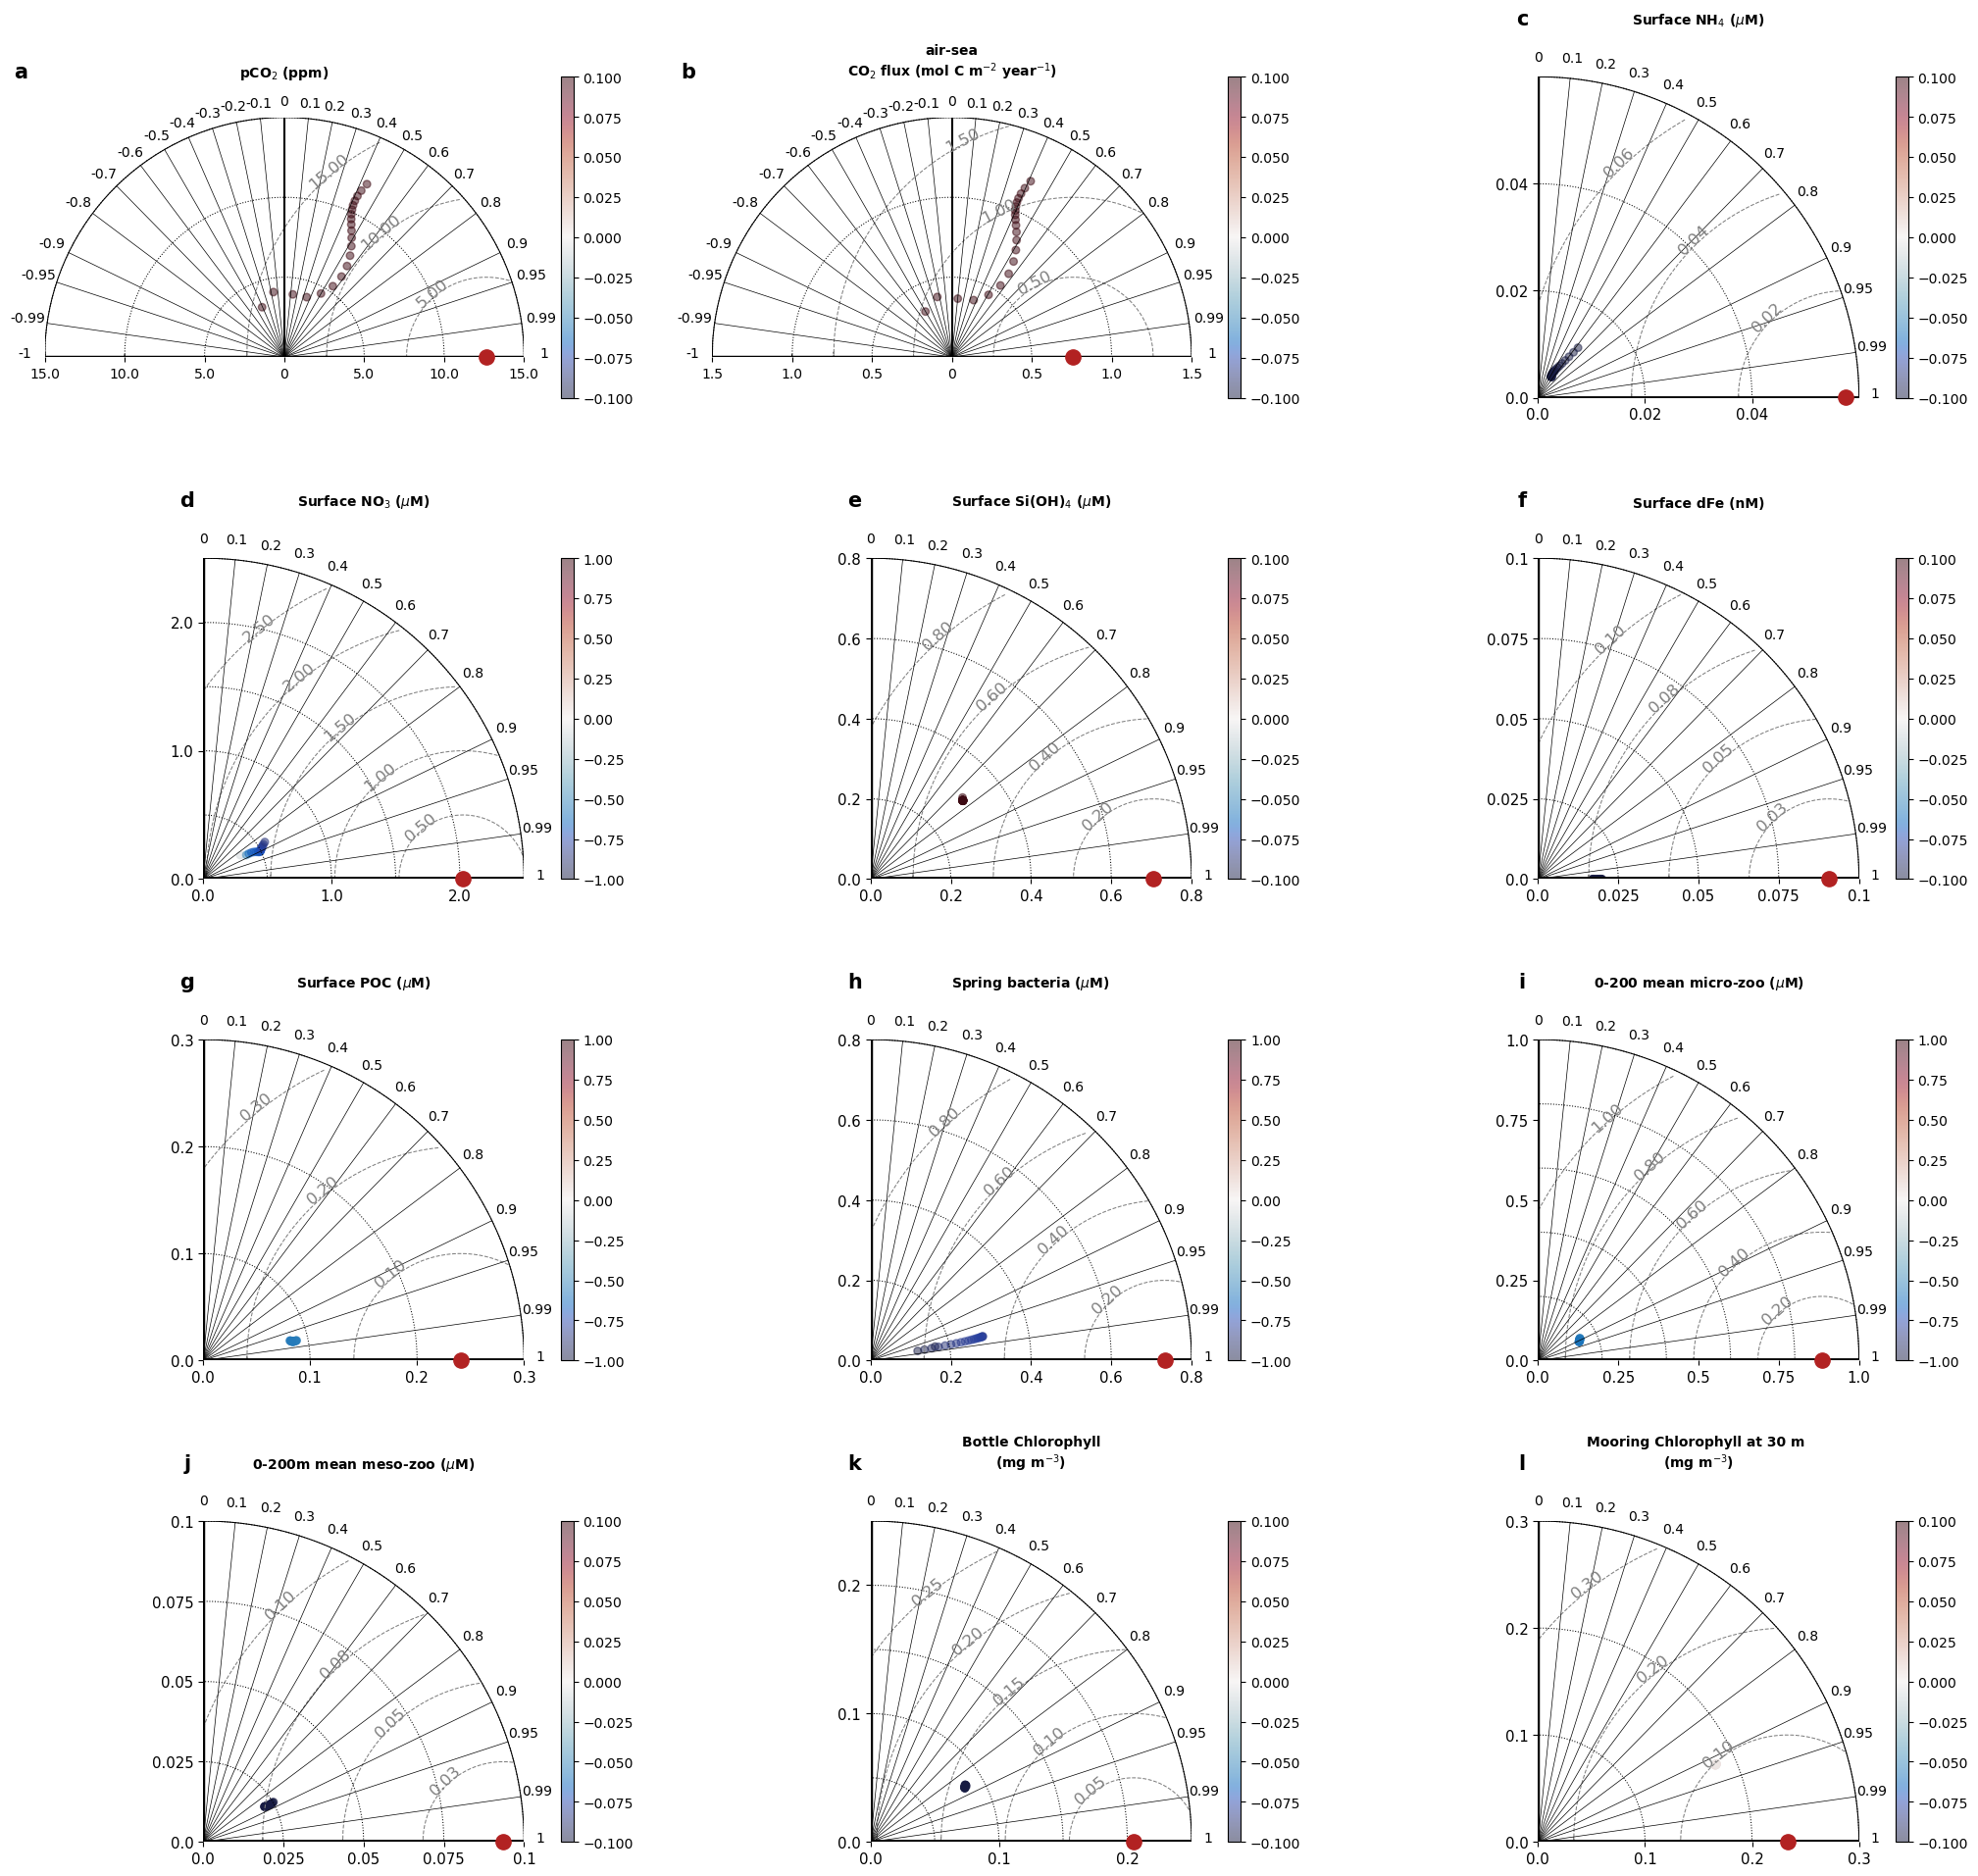

In [129]:

fslab = 15
fstic = 13

labs = ['pCO$_2$ (ppm)', \
        'air-sea\nCO$_2$ flux (mol C m$^{-2}$ year$^{-1}$)', \
        'Surface NH$_4$ ($\mu$M)', \
        'Surface NO$_3$ ($\mu$M)', \
        'Surface Si(OH)$_4$ ($\mu$M)', \
        'Surface dFe (nM)', \
        'Surface POC ($\mu$M)', \
        'Spring bacteria ($\mu$M)', \
        '0-200 mean micro-zoo ($\mu$M)', \
        '0-200m mean meso-zoo ($\mu$M)', \
        'Bottle Chlorophyll\n(mg m$^{-3}$)', \
        'Mooring Chlorophyll at 30 m \n(mg m$^{-3}$)'] 
letter = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']

fig = plt.figure(figsize=(22,20))
gs = GridSpec(4, 3)

for vi,vv in enumerate(target_vars[0:-2]):
    ax = plt.subplot(gs[vi])

    vmin = 0 - np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmax = 0 + np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmin = 0 - np.abs(np.round(np.min(stats[vv+'_bias'])))
    vmax = 0 + np.abs(np.round(np.min(stats[vv+'_bias'])))
    statss = stats

    
    sm.taylor_diagram(np.array(statss[vv+'_sdev']), np.array(statss[vv+'_crmsd']), np.array(statss[vv+'_ccoef']), alpha=0.1, 
                      MarkerDisplayed='colorBar', cmapzdata=np.array(statss[vv+'_bias']), locationColorBar='EastOutside', titleColorBar=' ', 
                      cmap=lighten(cmo.balance,0.5), cmap_marker='o', markerSize=15, cmap_vmax=vmax, cmap_vmin=vmin, 
                      colRMS='grey', styleRMS='--', widthRMS=0.75, showlabelsRMS='on', titleRMS='off', rmsLabelFormat='0:.2f',
                      colSTD='k', styleSTD=':', widthSTD=0.75, showlabelsSTD='off', titleSTD='off', 
                      colCOR='k', styleCOR='-', widthCOR=0.5, showlabelsCOR='on', titleCOR='off', 
                      markerOBS='o', colOBS='firebrick')

    plt.text(0.5,1.15, labs[vi], transform=ax.transAxes, va='bottom', ha='center', fontweight='bold')
    plt.text(-0.05,1.15, letter[vi], fontweight='bold', fontsize=fslab, ha='center', va='bottom', transform=ax.transAxes)


plt.subplots_adjust(hspace=0.5, wspace=0.1, right=0.95, left=0.05, bottom=0.05, top=0.95)



os.chdir("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures")
fig.savefig("assess_performance_TaylorDiagram_optimal.png", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_optimal.pdf", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_optimal_transparent.png", dpi=300, transparent=True)


### One taylor D for the best experiment

In [130]:
exps_subset = ['pa0p0', 'pa1p0_la0p0', 'pa1p0_la0p1', 'pa1p0_la0p20', 
               'pa1p0_la0p30', 'pa1p0_la0p40', 'pa1p0_la0p50', 
               'pa1p0_la0p60', 'pa1p0_la0p70', 'pa1p0_la0p80', 'pa1p0_la0p90']

In [131]:
target_vars

array(['dpco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac',
       'micro', 'meso', 'chl_bottle', 'chl_mooring', 'npp_CbPM',
       'npp_VGPM'], dtype='<U11')

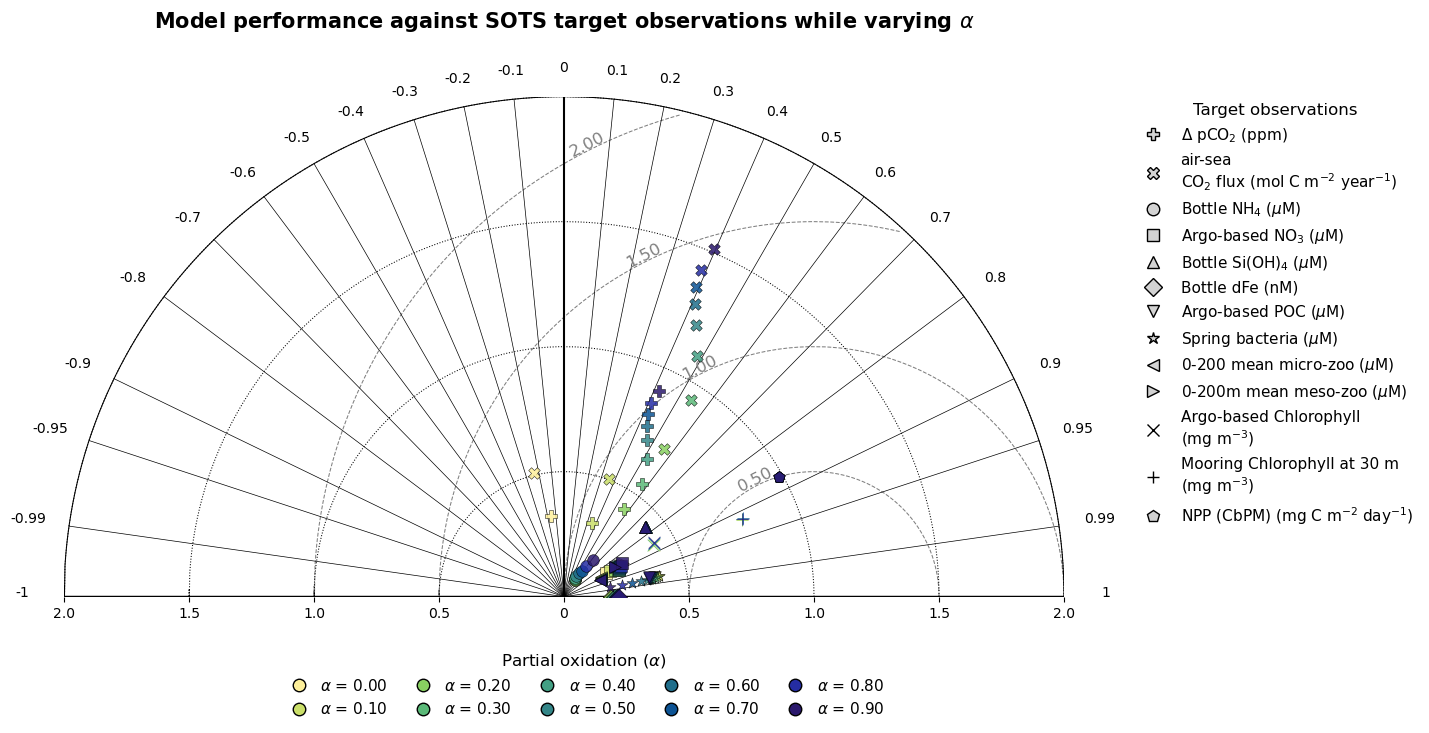

CPU times: user 4.46 s, sys: 467 ms, total: 4.93 s
Wall time: 4.18 s


In [132]:
%%time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

fslab = 15
fstic = 13

exps_subset = ['pa1p0_la0p0', 'pa1p0_la0p10', 'pa1p0_la0p20', 'pa1p0_la0p30', 'pa1p0_la0p40',
               'pa1p0_la0p50', 'pa1p0_la0p60', 'pa1p0_la0p70', 'pa1p0_la0p80', 'pa1p0_la0p90']
alpha_vals = np.arange(0.0, 1.0, 0.1)

target_vars = ["dpco2", "fgco2", "nh4", "no3", "sil", "dfe", "poc", "bac", "micro", "meso", "chl_bottle", "chl_mooring", "npp_CbPM"]

labs = ['$\Delta$ pCO$_2$ (ppm)',
        'air-sea\nCO$_2$ flux (mol C m$^{-2}$ year$^{-1}$)',
        'Bottle NH$_4$ ($\mu$M)',
        'Argo-based NO$_3$ ($\mu$M)',
        'Bottle Si(OH)$_4$ ($\mu$M)',
        'Bottle dFe (nM)',
        'Argo-based POC ($\mu$M)',
        'Spring bacteria ($\mu$M)',
        '0-200 mean micro-zoo ($\mu$M)',
        '0-200m mean meso-zoo ($\mu$M)',
        'Argo-based Chlorophyll\n(mg m$^{-3}$)',
        'Mooring Chlorophyll at 30 m \n(mg m$^{-3}$)',
        'NPP (CbPM) (mg C m$^{-2}$ day$^{-1}$)']

markers = ['P', 'X', 'o', 's', '^', 'D', 'v', '*', '<', '>', 'x', '+', 'p']

exp_to_stats_index = {exp: i + 1 for i, exp in enumerate(exps)}

def get_norm_taylor_stats(stats, vv, exp):
    idx = exp_to_stats_index[exp]
    obs_std = float(stats[f"{vv}_sdev"][0])
    std_norm = float(stats[f"{vv}_sdev"][idx]) / obs_std
    crmsd_norm = float(stats[f"{vv}_crmsd"][idx]) / obs_std
    corr = np.clip(float(stats[f"{vv}_ccoef"][idx]), -1.0, 1.0)
    return std_norm, crmsd_norm, corr

all_sdev = []
all_crmsd = []
all_ccoef = []

for exp in exps_subset:
    for vv in target_vars:
        sdev, crmsd, ccoef = get_norm_taylor_stats(stats, vv, exp)
        all_sdev.append(sdev)
        all_crmsd.append(crmsd)
        all_ccoef.append(ccoef)

all_sdev = np.array(all_sdev)
all_crmsd = np.array(all_crmsd)
all_ccoef = np.array(all_ccoef)

td_sdev = np.concatenate(([1.0], all_sdev))
td_crmsd = np.concatenate(([0.0], all_crmsd))
td_ccoef = np.concatenate(([1.0], all_ccoef))

fig = plt.figure(figsize=(20, 16))
ax = fig.add_axes([0.07, 0.20, 0.50, 0.68])
plt.sca(ax)

sm.taylor_diagram(td_sdev, td_crmsd, td_ccoef,
                  markerLabel=[''] * len(td_sdev), markerLegend='off', markerColor='white', markerSize=1, alpha=0.0,
                  colRMS='grey', styleRMS='--', widthRMS=0.75, showlabelsRMS='on', titleRMS='off', rmsLabelFormat='0:.2f',
                  colSTD='k', styleSTD=':', widthSTD=0.75, showlabelsSTD='on', titleSTD='off',
                  colCOR='k', styleCOR='-', widthCOR=0.5, showlabelsCOR='on', titleCOR='off',
                  markerOBS='o', colOBS='firebrick')

colmap = cmo.haline_r
norm = mpl.colors.Normalize(vmin=np.min(alpha_vals), vmax=np.max(alpha_vals))

for exp, alpha in zip(exps_subset, alpha_vals):
    col = colmap(norm(alpha))
    for ti, vv in enumerate(target_vars):
        sdev, crmsd, corr = get_norm_taylor_stats(stats, vv, exp)
        theta = np.arccos(corr)
        x = sdev * np.cos(theta)
        y = sdev * np.sin(theta)
        ax.scatter(x, y, s=70, marker=markers[ti], facecolor=col, edgecolor='k',
                   linewidth=0.4, alpha=0.85, zorder=10)

target_handles = [Line2D([0], [0], marker=markers[i], linestyle='None', markerfacecolor='lightgrey',
                         markeredgecolor='k', markersize=9, label=labs[i])
                  for i in range(len(target_vars))]

alpha_handles = [Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=colmap(norm(aval)),
                        markeredgecolor='k', markersize=9, label=rf"$\alpha$ = {aval:.2f}")
                 for aval in alpha_vals]

leg1 = fig.legend(handles=target_handles, title='Target observations', loc='center left',
                  bbox_to_anchor=(0.6, 0.56), bbox_transform=fig.transFigure,
                  fontsize=11, title_fontsize=12, frameon=False)

leg2 = fig.legend(handles=alpha_handles, title=r'Partial oxidation ($\alpha$)', loc='lower center',
                  bbox_to_anchor=(0.33, 0.3), bbox_transform=fig.transFigure,
                  fontsize=11, title_fontsize=12, ncols=5, frameon=False,
                  columnspacing=1.3, handletextpad=0.4)

plt.text(0.5, 1.15, r"Model performance against SOTS target observations while varying $\alpha$",
         fontsize=fslab, fontweight='bold', va='center', ha='center', transform=ax.transAxes)

plt.show()

fig.savefig("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/TaylorDiagram_12targets_SOTS.png", dpi=300, bbox_inches="tight")
fig.savefig("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/TaylorDiagram_12targets_SOTS_transparent.png", dpi=300, bbox_inches="tight", transparent=True)

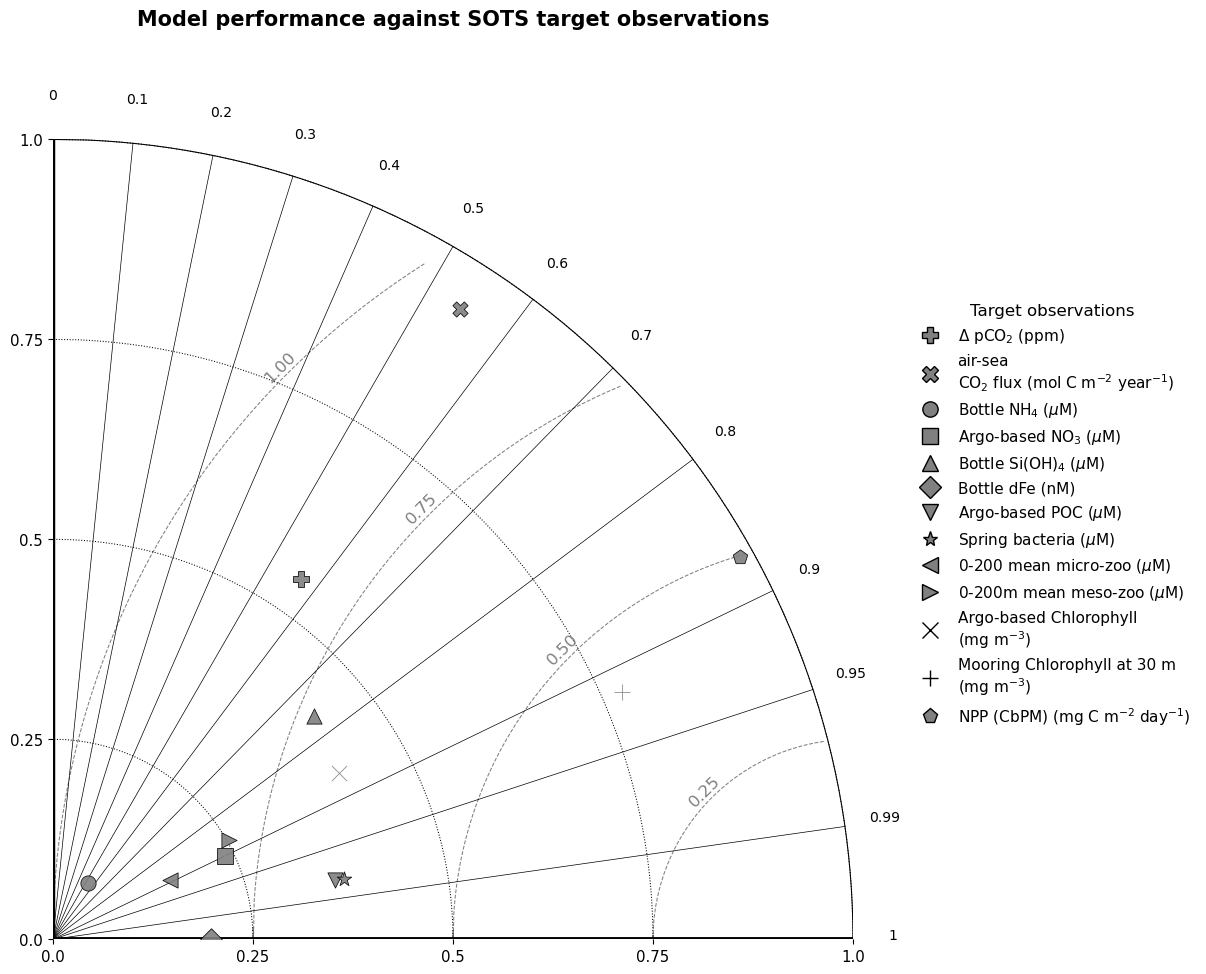

CPU times: user 3.32 s, sys: 329 ms, total: 3.65 s
Wall time: 2.97 s


In [136]:
%%time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fslab = 15
fstic = 13

exp = 'pa1p0_la0p30'

target_vars = ["dpco2", "fgco2", "nh4", "no3", "sil", "dfe", "poc", "bac", "micro", "meso", "chl_bottle", "chl_mooring", "npp_CbPM"]

labs = ['$\Delta$ pCO$_2$ (ppm)',
        'air-sea\nCO$_2$ flux (mol C m$^{-2}$ year$^{-1}$)',
        'Bottle NH$_4$ ($\mu$M)',
        'Argo-based NO$_3$ ($\mu$M)',
        'Bottle Si(OH)$_4$ ($\mu$M)',
        'Bottle dFe (nM)',
        'Argo-based POC ($\mu$M)',
        'Spring bacteria ($\mu$M)',
        '0-200 mean micro-zoo ($\mu$M)',
        '0-200m mean meso-zoo ($\mu$M)',
        'Argo-based Chlorophyll\n(mg m$^{-3}$)',
        'Mooring Chlorophyll at 30 m \n(mg m$^{-3}$)',
        'NPP (CbPM) (mg C m$^{-2}$ day$^{-1}$)']

markers = ['P', 'X', 'o', 's', '^', 'D', 'v', '*', '<', '>', 'x', '+', 'p']

exp_to_stats_index = {exp_name: i + 1 for i, exp_name in enumerate(exps)}

def get_norm_taylor_stats(stats, vv, exp):
    idx = exp_to_stats_index[exp]
    obs_std = float(stats[f"{vv}_sdev"][0])
    std_norm = float(stats[f"{vv}_sdev"][idx]) / obs_std
    crmsd_norm = float(stats[f"{vv}_crmsd"][idx]) / obs_std
    corr = np.clip(float(stats[f"{vv}_ccoef"][idx]), -1.0, 1.0)
    return std_norm, crmsd_norm, corr

all_sdev = []
all_crmsd = []
all_ccoef = []

for vv in target_vars:
    sdev, crmsd, ccoef = get_norm_taylor_stats(stats, vv, exp)
    all_sdev.append(sdev)
    all_crmsd.append(crmsd)
    all_ccoef.append(ccoef)

all_sdev = np.array(all_sdev)
all_crmsd = np.array(all_crmsd)
all_ccoef = np.array(all_ccoef)

td_sdev = np.concatenate(([1.0], all_sdev))
td_crmsd = np.concatenate(([0.0], all_crmsd))
td_ccoef = np.concatenate(([1.0], all_ccoef))

fig = plt.figure(figsize=(16, 12))
ax = fig.add_axes([0.07, 0.20, 0.50, 0.68])
plt.sca(ax)

sm.taylor_diagram(td_sdev, td_crmsd, td_ccoef,
                  markerLabel=[''] * len(td_sdev), markerLegend='off', markerColor='white', markerSize=1, alpha=0.0,
                  colRMS='grey', styleRMS='--', widthRMS=0.75, showlabelsRMS='on', titleRMS='off', rmsLabelFormat='0:.2f',
                  colSTD='k', styleSTD=':', widthSTD=0.75, showlabelsSTD='on', titleSTD='off',
                  colCOR='k', styleCOR='-', widthCOR=0.5, showlabelsCOR='on', titleCOR='off',
                  markerOBS='o', colOBS='firebrick')

point_color = "grey"

for ti, vv in enumerate(target_vars):
    sdev, crmsd, corr = get_norm_taylor_stats(stats, vv, exp)
    theta = np.arccos(corr)
    x = sdev * np.cos(theta)
    y = sdev * np.sin(theta)
    ax.scatter(x, y, s=120, marker=markers[ti], facecolor=point_color, edgecolor='k',
               linewidth=0.6, alpha=0.90, zorder=10)

target_handles = [Line2D([0], [0], marker=markers[i], linestyle='None', markerfacecolor=point_color,
                         markeredgecolor='k', markersize=11, label=labs[i])
                  for i in range(len(target_vars))]

leg1 = fig.legend(handles=target_handles, title='Target observations', loc='center left',
                  bbox_to_anchor=(0.60, 0.56), bbox_transform=fig.transFigure,
                  fontsize=11, title_fontsize=12, frameon=False)

plt.text(0.5, 1.15, "Model performance against SOTS target observations",
         fontsize=fslab, fontweight='bold', va='center', ha='center', transform=ax.transAxes)

plt.show()

fig.savefig(f"/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/TaylorDiagram_12targets_SOTS_exp{exp}.png",
            dpi=300, bbox_inches="tight")

fig.savefig(f"/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/TaylorDiagram_12targets_SOTS_exp{exp}_transparent.png",
            dpi=300, bbox_inches="tight", transparent=True)


### RQ and summer CO2 uptake

In [137]:
%%time

exps_subset

CPU times: user 10 μs, sys: 0 ns, total: 10 μs
Wall time: 20.3 μs


['pa1p0_la0p0',
 'pa1p0_la0p10',
 'pa1p0_la0p20',
 'pa1p0_la0p30',
 'pa1p0_la0p40',
 'pa1p0_la0p50',
 'pa1p0_la0p60',
 'pa1p0_la0p70',
 'pa1p0_la0p80',
 'pa1p0_la0p90']

In [138]:
%%time


# Extract the daily timestamps that fall on the 15th of each month
month_times = mod['dic_stf_%s'%(exps[0])]['time'].where(mod['dic_stf_%s'%(exps[0])]['time'].dt.day == 15, drop=True)

# Replace month dimension with time dimension
obs_fgco2 = (
    obsdata['fgco2']
    .rename({'month': 'time'})
    .assign_coords(time=month_times.values)
)

# Replace month dimension with time dimension
obs_dpco2 = (
    obsdata['dpco2']
    .rename({'month': 'time'})
    .assign_coords(time=month_times.values)
)


CPU times: user 26.7 ms, sys: 8.14 ms, total: 34.9 ms
Wall time: 353 ms


### plot pCO2 and fgCO2, phase diagram of partial_ox vs summer CO2 uptake


In [152]:
%%time

obs_time = obs_dpco2.indexes['time'].to_datetimeindex()
mod_time = mod['dic_stf_pa1p0_la0p0'].indexes['time'].to_datetimeindex()
mod_time


CPU times: user 8.79 ms, sys: 0 ns, total: 8.79 ms
Wall time: 8.37 ms


DatetimeIndex(['1909-01-01 12:00:00', '1909-01-02 12:00:00',
               '1909-01-03 12:00:00', '1909-01-04 12:00:00',
               '1909-01-05 12:00:00', '1909-01-06 12:00:00',
               '1909-01-07 12:00:00', '1909-01-08 12:00:00',
               '1909-01-09 12:00:00', '1909-01-10 12:00:00',
               ...
               '1909-12-22 12:00:00', '1909-12-23 12:00:00',
               '1909-12-24 12:00:00', '1909-12-25 12:00:00',
               '1909-12-26 12:00:00', '1909-12-27 12:00:00',
               '1909-12-28 12:00:00', '1909-12-29 12:00:00',
               '1909-12-30 12:00:00', '1909-12-31 12:00:00'],
              dtype='datetime64[ns]', length=365, freq=None)

#### get summer averages

In [140]:
%%time

summer_mask = mod['dic_stf_pa1p0_la0p0'].coords['time'].dt.month.isin([12, 1, 2])
    
for exp in exps:
    mod['summer_pco2_%s'%(exp)] = mod['pco2_%s'%(exp)].where(summer_mask, drop=True)
    mod['summer_fgco2_%s'%(exp)] = mod['dic_stf_%s'%(exp)].where(summer_mask, drop=True)
    mod['summer_RQ_%s'%(exp)] = mod['RQ_%s'%(exp)].sel(zl=slice(0,20)).where(summer_mask, drop=True)
    mod['summer_lbacRQ_%s'%(exp)] = mod['lbacRQ_%s'%(exp)].sel(zl=slice(0,20)).where(summer_mask, drop=True)
    mod['summer_doc_%s'%(exp)] = mod['doc_%s'%(exp)].sel(zl=slice(0,20)).where(summer_mask, drop=True)
    mod['summer_dfe_%s'%(exp)] = mod['fe_%s'%(exp)].sel(zl=slice(0,20)).where(summer_mask, drop=True)
    mod['summer_chl_%s'%(exp)] = mod['pchl_%s'%(exp)].sel(zl=slice(0,20)).where(summer_mask, drop=True) + mod['dchl_%s'%(exp)].sel(zl=slice(0,20)).where(summer_mask, drop=True)

for exp in exps:
    mod['annual_dpco2_R_%s'%(exp)] = np.corrcoef(mod['pco2_%s_obsgrid'%(exp)].values-395.30, obs_dpco2)[0][1]
    mod['annual_fgco2_R_%s'%(exp)] = np.corrcoef(mod['fgco2_%s_obsgrid'%(exp)].values, obs_fgco2)[0][1]
    mod['annual_dpco2_RMSE_%s'%(exp)] = np.sqrt(np.mean(((mod['pco2_%s_obsgrid'%(exp)].values-395.30) - obs_dpco2)**2))
    mod['annual_fgco2_RMSE_%s'%(exp)] = np.sqrt(np.mean((mod['fgco2_%s_obsgrid'%(exp)].values - obs_dpco2)**2))


CPU times: user 1.6 s, sys: 357 ms, total: 1.96 s
Wall time: 2.62 s


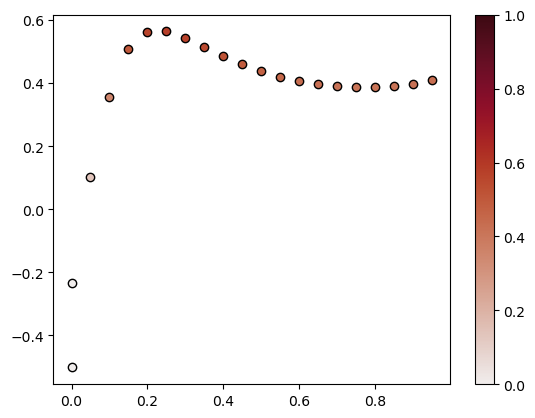

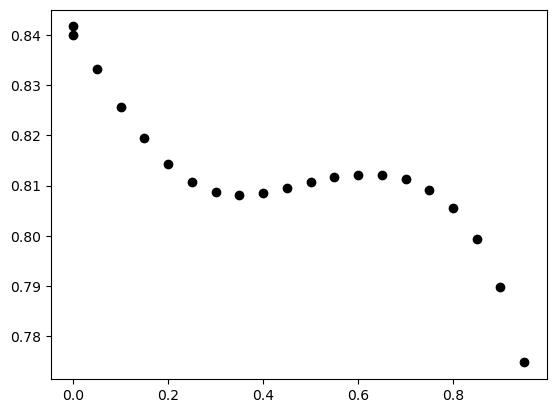

In [141]:
#print(" ")
#for exp in np.arange(101,121,1):
#    xx = (exp-100) * 0.05 - 0.05
#    print(xx, mod['annual_fgco2_R2_%i'%(exp)], mod['annual_dpco2_R2_%i'%(exp)])

#print(" ")
#for exp in np.arange(121,141,1):
#    xx = (exp-120) * 0.05 - 0.05
#    print(xx, mod['annual_fgco2_R2_%i'%(exp)], mod['annual_dpco2_R2_%i'%(exp)])

alpha_vals = np.concatenate((np.array([0.0]), np.arange(0.0,1.0,0.05)))

plt.figure()
ax = plt.subplot()
for ii,exp in enumerate(exps):
    alpha = alpha_vals[ii]
    p1 = ax.scatter(alpha, mod['annual_fgco2_R_%s'%(exp)], c=mod['annual_dpco2_R_%s'%(exp)], cmap=cmo.amp, vmin=0, vmax=1.0, marker='o', edgecolor='k')
plt.colorbar(p1)


plt.figure()
ax = plt.subplot()
for ii,exp in enumerate(exps):
    alpha = alpha_vals[ii]
    p1 = ax.scatter(alpha, mod['summer_RQ_%s'%(exp)].mean(dim=['time','zl']), color='k')
    

In [144]:
%%time
summer_mask = obs_dpco2.coords['time'].dt.month.isin([12, 1, 2])
summer_mask

summer_obs_fgco2 = obs_fgco2.where(summer_mask, drop=True)
summer_obs_dpco2 = obs_dpco2.where(summer_mask, drop=True)


CPU times: user 10.4 ms, sys: 4.94 ms, total: 15.3 ms
Wall time: 14.3 ms


In [145]:
summer_obs_fgco2.mean(dim='time')

<xarray.DataArray 'co2_flux_mol_m2_y1' ()> Size: 8B
array(-2.17474979)
Coordinates:
    depth    float64 8B 0.0

In [101]:
for exp in exps:
    print(exp, mod['annual_fgco2_R_%s'%(exp)], mod['summer_fgco2_%s'%(exp)].mean(dim='time').values*365*86400*-1)

pa0p0 -0.7680700333650302 -0.2225147320800147
pa1p0_la0p0 -0.6107909998947773 -0.43310810451657744
pa1p0_la0p05 -0.4429145257781934 -0.6215953105197514
pa1p0_la0p10 -0.21788315034686545 -0.6452455478722641
pa1p0_la0p15 0.06834636297680746 -0.7303949396657572
pa1p0_la0p20 0.28681732766279855 -0.8495577266955934
pa1p0_la0p25 0.4021292297791792 -0.9705146403007348
pa1p0_la0p30 0.44716642356119096 -1.0900791969561396
pa1p0_la0p35 0.45411751545020446 -1.2027019677134376
pa1p0_la0p40 0.4431162265061146 -1.3047429376911168
pa1p0_la0p45 0.42494501536717677 -1.3938833606061962
pa1p0_la0p50 0.4053893156393607 -1.4700434651331307
pa1p0_la0p55 0.38727512402035963 -1.5344346102210693
pa1p0_la0p60 0.3719737731504953 -1.5893403621021207
pa1p0_la0p65 0.35998224950777136 -1.6371482586237107
pa1p0_la0p70 0.35166111293083957 -1.6811916656251924
pa1p0_la0p75 0.3472285128196839 -1.7249165475163863
pa1p0_la0p80 0.3470579767324394 -1.7725112350035488
pa1p0_la0p85 0.3516635949538505 -1.8292004137947515
pa1p0_

### re-order the datasets to go from July to June, not Jan to Dec

In [146]:
%%time

cbpm_xr = xr.concat([cbpm_xr.sel(day=slice(185,None)), cbpm_xr.sel(day=slice(None,177))], dim='day').assign_coords(day=cbpm_xr.day)
vgpm_xr = xr.concat([vgpm_xr.sel(day=slice(185,None)), vgpm_xr.sel(day=slice(None,177))], dim='day').assign_coords(day=vgpm_xr.day)
mod_npp_8day = xr.concat([mod_npp_8day.sel(day=slice(185,None)), mod_npp_8day.sel(day=slice(None,177))], dim='day').assign_coords(day=mod_npp_8day.day)


CPU times: user 24.7 ms, sys: 2.54 ms, total: 27.2 ms
Wall time: 46.7 ms


In [147]:
%%time

for exp in exps:
    mod['dic_stf_%s_wrap'%(exp)] = xr.concat([mod['dic_stf_%s'%(exp)].isel(time=slice(181,None)), mod['dic_stf_%s'%(exp)].isel(time=slice(0,181))], dim='time').assign_coords(time=mod['dic_stf_%s'%(exp)].time)
    mod['doc_%s_wrap'%(exp)] = xr.concat([mod['doc_%s'%(exp)].isel(time=slice(181,None)), mod['doc_%s'%(exp)].isel(time=slice(0,181))], dim='time').assign_coords(time=mod['dic_stf_%s'%(exp)].time)



CPU times: user 155 ms, sys: 13.3 ms, total: 168 ms
Wall time: 157 ms


In [150]:
%%time

obs_fgco2_wrap = xr.concat([obs_fgco2.sel(time=slice("1909-07-01","1909-12-31")), obs_fgco2.sel(time=slice("1909-01-01","1909-06-30"))], dim='time')
obs_dpco2_wrap = xr.concat([obs_dpco2.sel(time=slice("1909-07-01","1909-12-31")), obs_dpco2.sel(time=slice("1909-01-01","1909-06-30"))], dim='time')


CPU times: user 9.93 ms, sys: 859 μs, total: 10.8 ms
Wall time: 10.5 ms


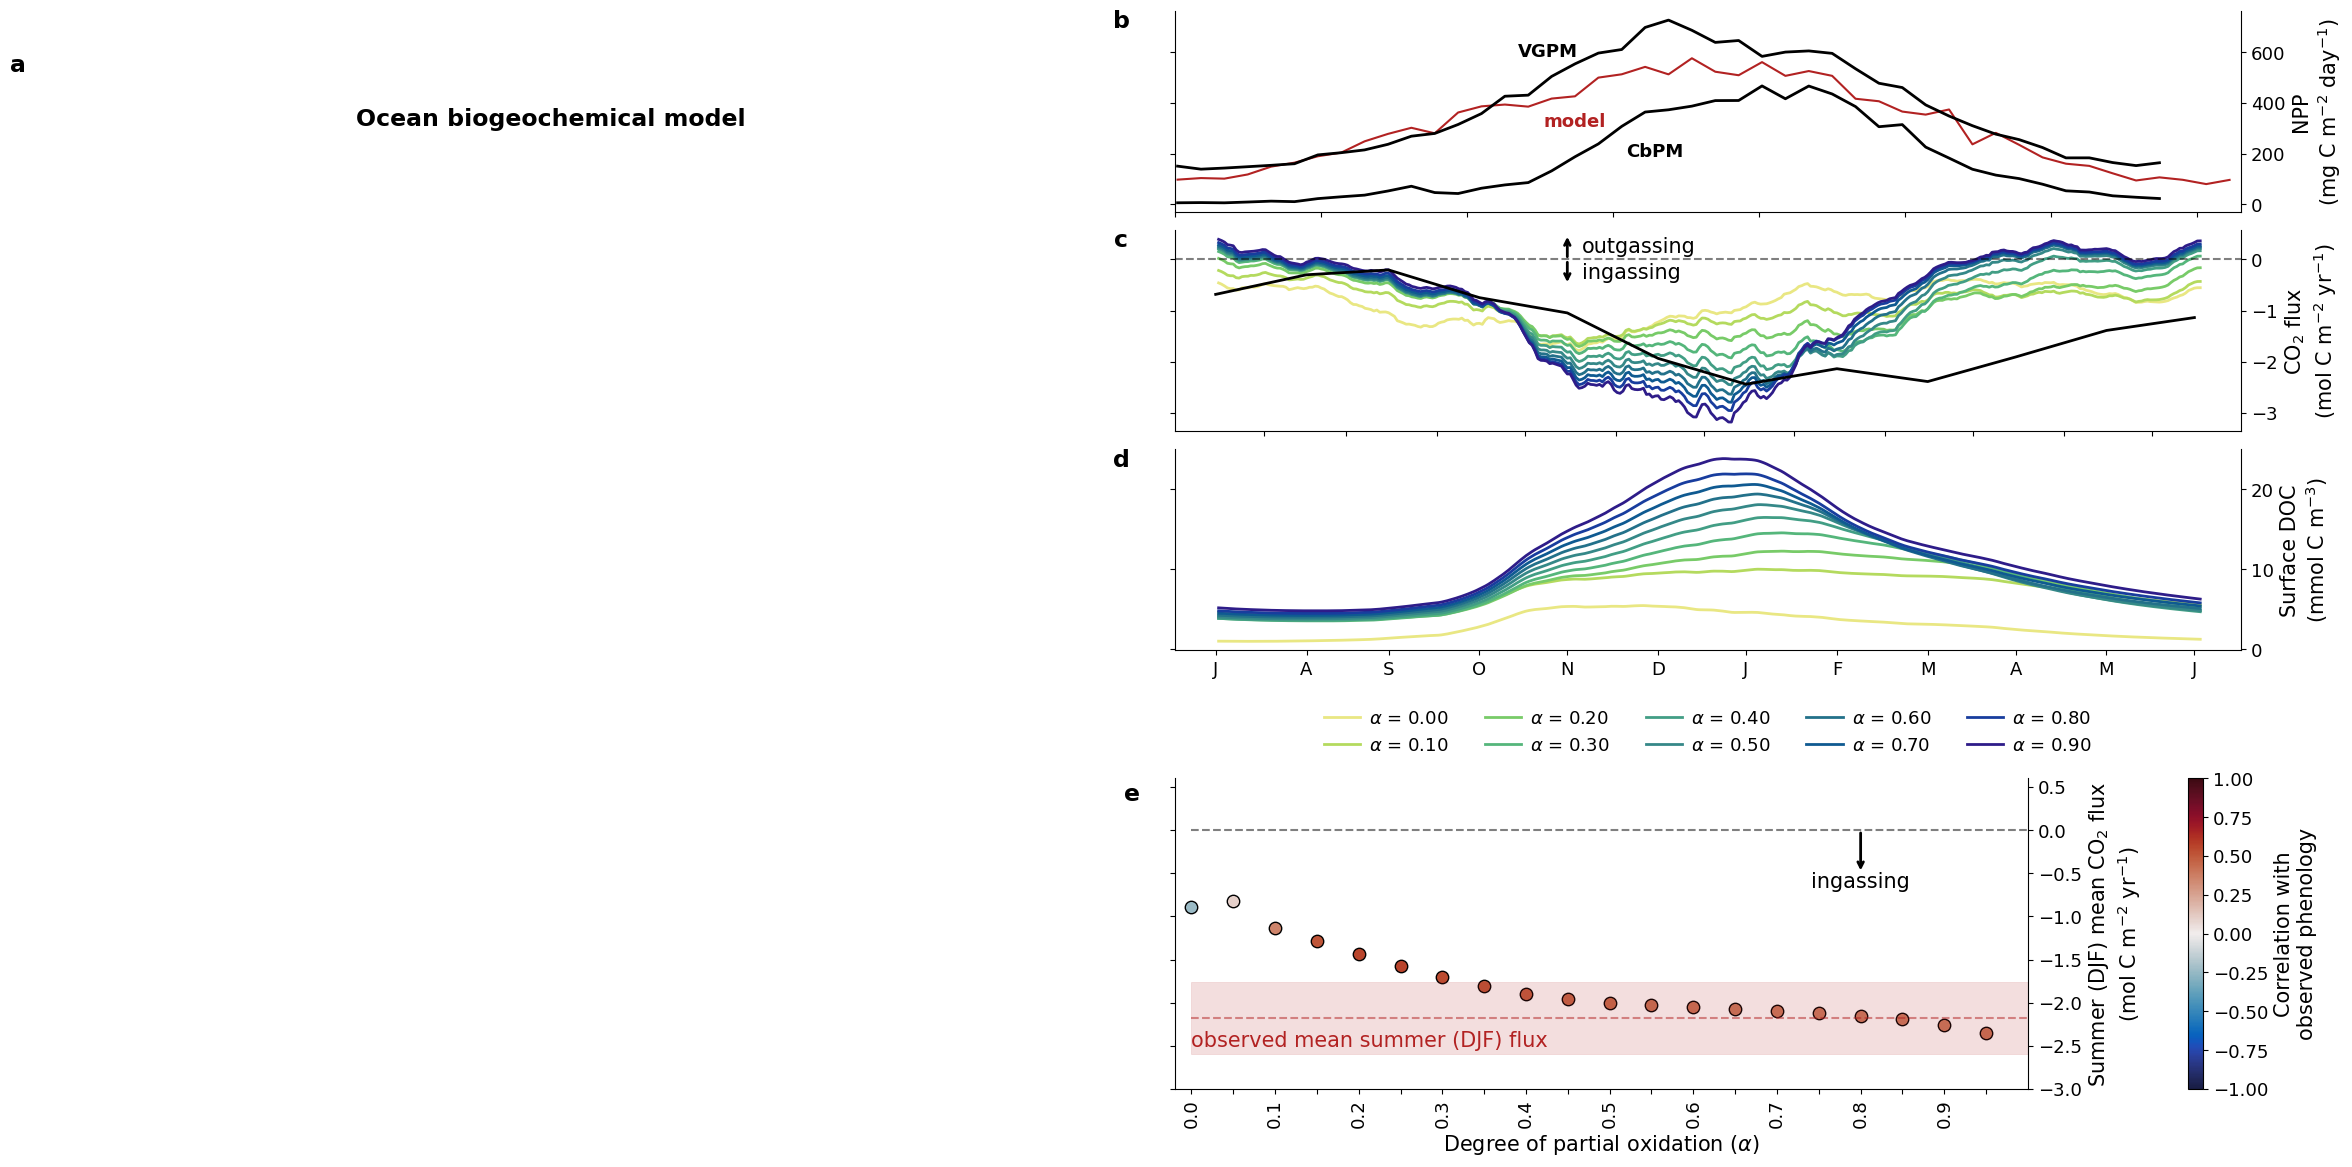

In [172]:

fstic = 13
fslab = 15
colmap = cmo.haline_r
colors = colmap(np.linspace(0, 1, 21))
lwid = 2.0
lsty = '-'
alf = 1.0

alpha_vals = np.concatenate((np.array([0.0]), np.arange(0.0, 1.0, 0.05)))
labs = [r'$\alpha$ = %.2f' % a for a in alpha_vals]

# Experiments shown in seasonal-cycle panels
plot_idx = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

fig = plt.figure(figsize=(28,14))
gs = GridSpec(10,10)

ax1 = plt.subplot(gs[:,0:5])
ax2 = plt.subplot(gs[0:2,5:10])
ax3 = plt.subplot(gs[2:4,5:10])
ax4 = plt.subplot(gs[4:6,5:10])
ax5 = plt.subplot(gs[7:10,5:10])

ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False, labelsize=fstic)
ax2.tick_params(labelleft=False, labelbottom=False, right=True, labelright=True, labelsize=fstic)
ax3.tick_params(labelleft=False, labelbottom=False, right=True, labelright=True, labelsize=fstic)
ax4.tick_params(labelleft=False, labelbottom=True, right=True, labelright=True, labelsize=fstic)
ax5.tick_params(labelleft=False, labelbottom=True, right=True, labelright=True, labelsize=fstic)

ax1.spines[['top','left','right','bottom']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax3.spines[['top']].set_visible(False)
ax4.spines[['top']].set_visible(False)
ax5.spines[['top']].set_visible(False)

# Air-sea CO2 flux seasonal cycle
ax2.plot(cbpm_xr.coords['day'], cbpm_xr.mean(dim=['x', 'y', 'year']), color='k', zorder=3, linewidth=2.0)
ax2.plot(cbpm_xr.coords['day'], vgpm_xr.mean(dim=['x', 'y', 'year']), color='k', zorder=3, linewidth=2.0)
ax2.plot(mod_npp_8day.coords['day'], mod_npp_8day.values * 1e3 * 12 * 86400, color='firebrick')
ax3.plot(obs_time, obs_fgco2_wrap, color='k', zorder=3, linewidth=2.0)
ax3.plot(mod_time, mod['dic_stf_pa0p0']*0.0, 'k--', alpha=0.5, linewidth=1.5, zorder=3)
ax5.plot(mod_time, mod['dic_stf_pa0p0']*0.0, 'k--', alpha=0.5, linewidth=1.5, zorder=3)

window = 30

for idx in plot_idx:
    exp = exps[idx]
    c = colors[idx]
    ax3.plot(mod_time, mod[f'dic_stf_{exp}_wrap'].rolling(time=window, center=True).mean()*86400*365*-1, color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2, label=labs[idx])

for idx in plot_idx:
    exp = exps[idx]
    c = colors[idx]
    ax4.plot(mod_time, mod[f'doc_{exp}_wrap'].isel(zl=0).rolling(time=window, center=True).mean()*1e6*1.035, color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2, label=labs[idx])

# Summer flux versus alpha
for j, alpha in enumerate(alpha_vals[1::]):
    c = colors[j+1]
    exp = exps[j+1]
    p5 = ax5.scatter(alpha, mod[f'summer_fgco2_{exp}'].mean(dim='time')*86400*365*(-1),
                     c=mod['annual_fgco2_R_%s'%(exp)], cmap=cmo.balance, vmin=-1.0, vmax=1.0,
                     edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[j])
x_alpha = np.arange(0.0, 1.01, 0.1)
ax5.plot(x_alpha, x_alpha*0, color='k', linestyle='--', linewidth=1.5, alpha=0.5, zorder=3)
ax5.plot(x_alpha, x_alpha*0 + summer_obs_fgco2.mean(dim='time').values,
         color='firebrick', linestyle='--', linewidth=1.5, alpha=0.5, zorder=3)
ax5.fill_between(x_alpha,
                 x_alpha*0 + summer_obs_fgco2.mean(dim='time').values - summer_obs_fgco2.std(dim='time').values*2,
                 x_alpha*0 + summer_obs_fgco2.mean(dim='time').values + summer_obs_fgco2.std(dim='time').values*2,
                 color='firebrick', linewidth=0.5, alpha=0.15, zorder=1)
plt.text(0.0, summer_obs_fgco2.mean(dim='time').values-0.15, 'observed mean summer (DJF) flux',
         fontsize=fslab, ha='left', va='top', color='firebrick', transform=ax5.transData)

## Summer flux versus alpha
#for j, alpha in enumerate(alpha_vals[1::]):
#    c = colors[j+1]
#    exp = exps[j+1]
#    p5 = ax5.scatter(alpha, mod[f'summer_RQ_{exp}'].mean(dim=['time']).isel(zl=0),
#                     c=mod[f'summer_lbacRQ_{exp}'].mean(dim=['time']).isel(zl=0), cmap=cmo.balance, vmin=0.0, vmax=1.0,
#                     edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[j])
#    #p5 = ax5.scatter(alpha, mod[f'summer_lbacRQ_{exp}'].mean(dim=['time']).isel(zl=0),
#    #                 c=mod['annual_fgco2_R_%s'%(exp)], cmap=cmo.balance, vmin=-1.0, vmax=1.0,
#    #                 edgecolor='k', linewidth=lwid*0.5, s=80, marker='p', label=labs[j])


ax4.set_xticks(obs_time, ['J', 'A', 'S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J'])
ax5.set_xticks(alpha_vals[1::], np.array([0.0, "", 0.1, "", 0.2, "", 0.3, "", 0.4, "", 0.5, "", 0.6, "", 0.7, "", 0.8, "", 0.9, ""]), rotation=90)

ax2.set_ylabel('NPP\n(mg C m$^{-2}$ day$^{-1}$)', fontsize=fslab)
ax3.set_ylabel('CO$_2$ flux\n(mol C m$^{-2}$ yr$^{-1}$)', fontsize=fslab)
ax4.set_ylabel('Surface DOC\n(mmol C m$^{-3}$)', fontsize=fslab)
ax5.set_xlabel(r'Degree of partial oxidation ($\alpha$)', fontsize=fslab)
ax5.set_ylabel('Summer (DJF) mean CO$_2$ flux\n(mol C m$^{-2}$ yr$^{-1}$)', fontsize=fslab)

#plt.text(0.5, 0.95, 'summer (DJF) mean', fontsize=fslab, color='k', ha='center', va='center', transform=ax5.transAxes)

ax2.yaxis.set_label_position('right')
ax3.yaxis.set_label_position('right')
ax4.yaxis.set_label_position('right')
ax5.yaxis.set_label_position('right')

plt.text(0.35, 0.8, 'VGPM', va='center', ha='center', fontweight='bold', fontsize=fstic, transform=ax2.transAxes)
plt.text(0.375, 0.45, 'model', va='center', ha='center', fontweight='bold', fontsize=fstic, transform=ax2.transAxes, color='firebrick')
plt.text(0.45, 0.3, 'CbPM', va='center', ha='center', fontweight='bold', fontsize=fstic, transform=ax2.transAxes)

t = pd.Timestamp("1909-05-15 12:00:00")
td = pd.Timedelta(days=5)
ax3.annotate("", xy=(t, -0.5), xytext=(t, 0.0), arrowprops=dict(arrowstyle="->", linewidth=2.0))
plt.text(t+td, -0.25, 'ingassing', fontsize=fslab, color='k', ha='left', va='center', transform=ax3.transData)
ax3.annotate("", xy=(t, +0.5), xytext=(t, 0.0), arrowprops=dict(arrowstyle="->", linewidth=2.0))
plt.text(t+td, +0.25, 'outgassing', fontsize=fslab, color='k', ha='left', va='center', transform=ax3.transData)

ax5.annotate("", xy=(0.8, -0.5), xytext=(0.8, 0.0), arrowprops=dict(arrowstyle="->", linewidth=2.0))
plt.text(0.8, -0.6, 'ingassing', fontsize=fslab, color='k', ha='center', va='center', transform=ax5.transData)

ax4.legend(frameon=False, ncols=5, bbox_to_anchor=(0.5,-0.6), loc='lower center',
           fontsize=13, columnspacing=2, handletextpad=0.5)

ax5.set_xlim(-0.02,1.0)
ax5.set_ylim(-3,0.6)

cb5 = plt.colorbar(p5, ax=ax5, orientation='vertical', fraction=0.05, aspect=20, pad=0.15)
cb5.ax.set_ylabel("Correlation with\nobserved phenology", fontsize=fslab)
cb5.ax.tick_params(labelsize=fstic)

plt.text(0.45, 0.90, "Ocean biogeochemical model", fontsize=17, fontweight='bold',
         va='center', ha='center', transform=ax1.transAxes)

ax2.set_xlim(0,365)
ax3.set_xlim(pd.Timestamp("1909-01-01 12:00:00"), pd.Timestamp("1909-12-31 12:00:00"))
ax4.set_xlim(pd.Timestamp("1909-01-01 12:00:00"), pd.Timestamp("1909-12-31 12:00:00"))


xx = -0.05
yy = 0.95
plt.text(xx, yy, 'a', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax1.transAxes)
plt.text(xx, yy, 'b', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax2.transAxes)
plt.text(xx, yy, 'c', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax3.transAxes)
plt.text(xx, yy, 'd', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax4.transAxes)
plt.text(xx, yy, 'e', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax5.transAxes)

fig.savefig("../figures/CO2cycle_4MF.png", dpi=300, bbox_inches='tight')

['$\\alpha$ = 0.00', '$\\alpha$ = 0.05', '$\\alpha$ = 0.10', '$\\alpha$ = 0.15', '$\\alpha$ = 0.20', '$\\alpha$ = 0.25', '$\\alpha$ = 0.30', '$\\alpha$ = 0.35', '$\\alpha$ = 0.40', '$\\alpha$ = 0.45', '$\\alpha$ = 0.50', '$\\alpha$ = 0.55', '$\\alpha$ = 0.60', '$\\alpha$ = 0.65', '$\\alpha$ = 0.70', '$\\alpha$ = 0.75', '$\\alpha$ = 0.80', '$\\alpha$ = 0.85', '$\\alpha$ = 0.90', '$\\alpha$ = 0.95']


TypeError: list indices must be integers or slices, not tuple

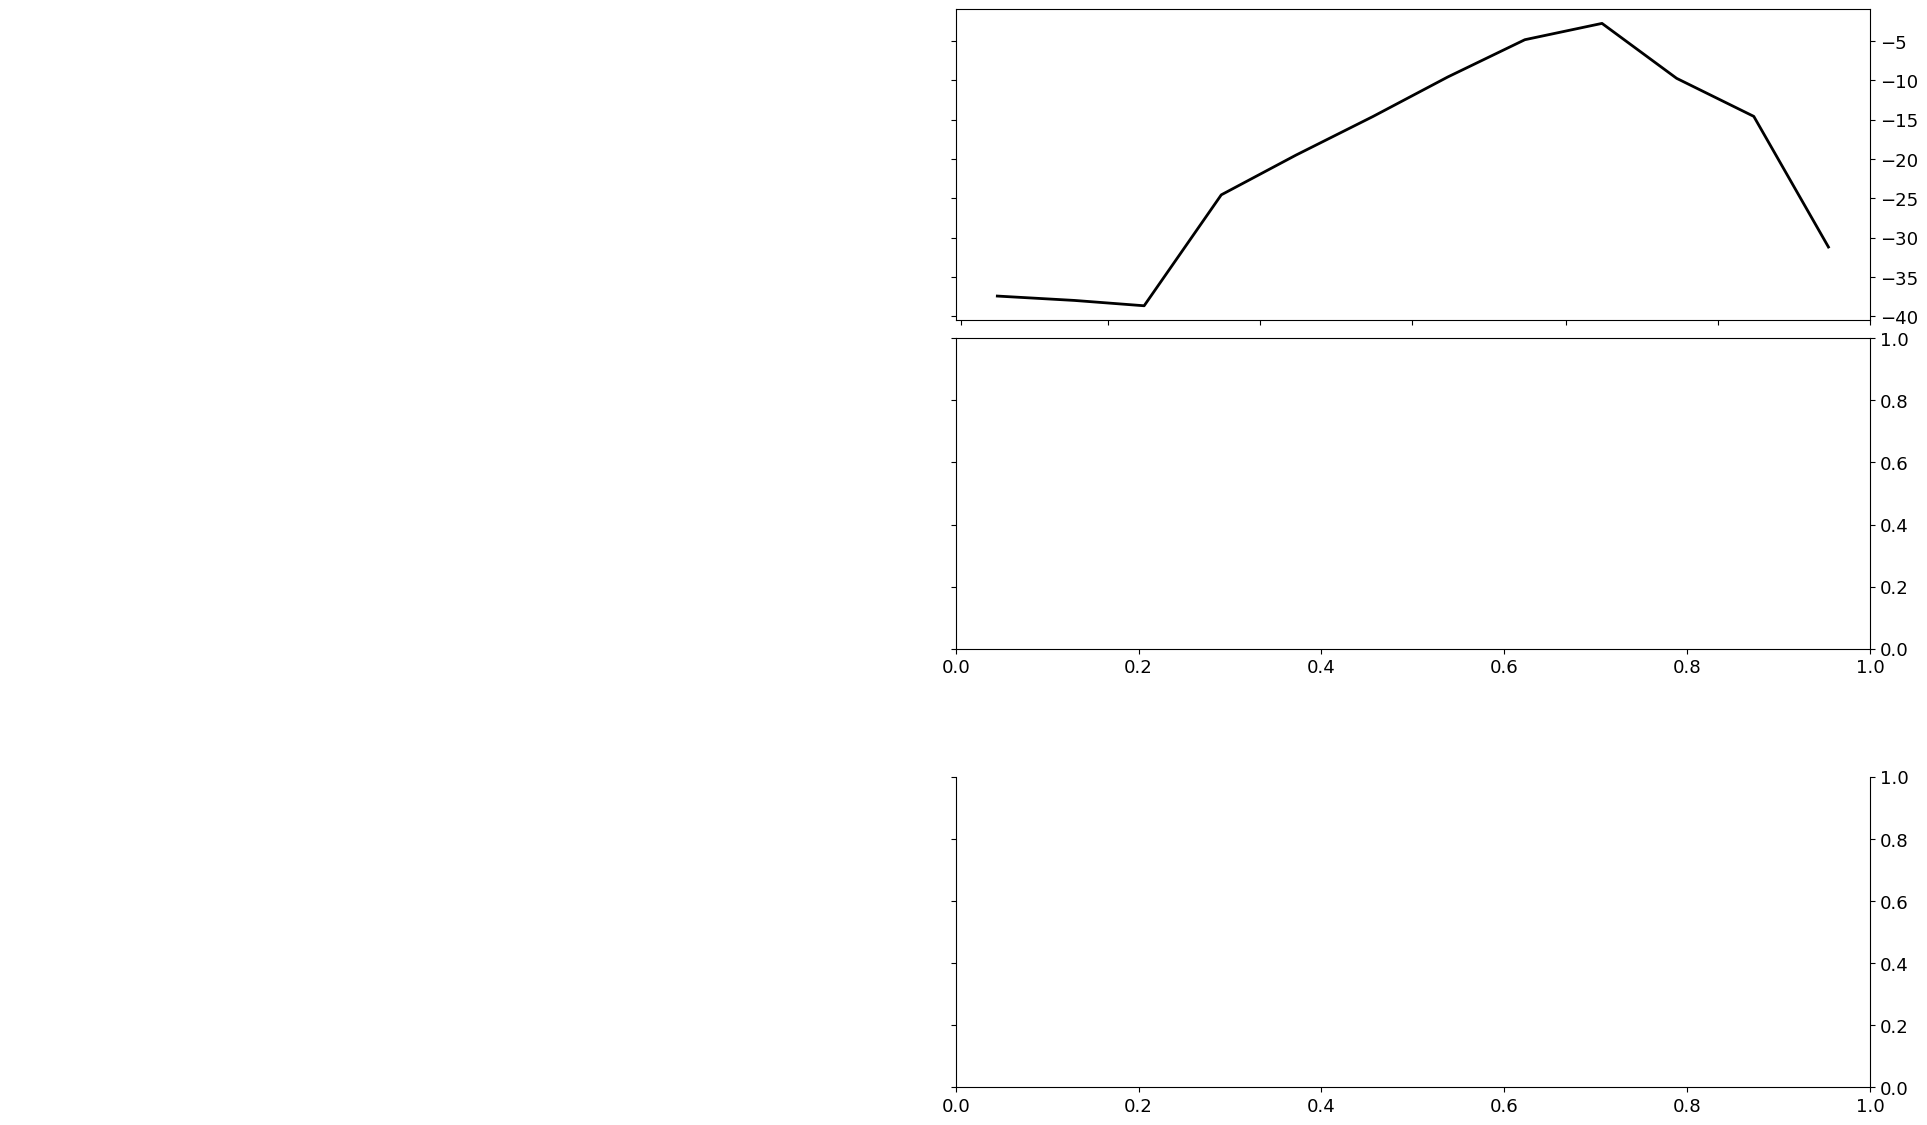

In [60]:

fstic = 13
fslab = 15
colmap = cmo.haline_r
colors = colmap(np.linspace(0, 1, 20))
lwid = 1.0
lsty = '-'
alf = 1.0

labs = []
for i in np.arange(0.0, 0.96,0.05):
    labs.append(r'$\alpha$ = %.2f'%(i))
print(labs)

fig = plt.figure(figsize=(24,14))
gs = GridSpec(10,10)

ax1 = plt.subplot(gs[:,0:5])
ax2 = plt.subplot(gs[0:3,5:10])
ax3 = plt.subplot(gs[3:6,5:10])
#ax4 = plt.subplot(gs[7:10,5:7])
ax5 = plt.subplot(gs[7:10,5:10])

ax1.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False, labelsize=fstic)
ax2.tick_params(labelleft=False, labelbottom=False, right=True, labelright=True, labelsize=fstic)
ax3.tick_params(labelleft=False, labelbottom=True, right=True, labelright=True, labelsize=fstic)
ax5.tick_params(labelleft=False, labelbottom=True, right=True, labelright=True, labelsize=fstic)

ax1.spines[['top','left','right','bottom']].set_visible(False)
ax5.spines[['top']].set_visible(False)

ax2.plot(obs_time, obs_dpco2, 'k', zorder=3, linewidth=2.0, label='observed seasonal climatology')
for i in exps[1,3,5,7,9,11,13,15,17,19]:
    c = colors[i]
    ax2.plot(mod_time, mod['pco2_%s'%(i)]-395.30, color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2)

ax3.plot(obs_time, obs_fgco2, color='k', zorder=3, linewidth=2.0)
ax3.plot(mod_time, mod['dic_stf_1'] * 0.0, 'k--', alpha=0.5, linewidth=1.5, zorder=3)
for i in [1,3,5,7,9,11,13,14,15,16,17]:
    c = colors[i]
    ax3.plot(mod_time, mod['dic_stf_%i'%(i+120)]*86400*365*(-1), color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2)

for i in np.arange(1,21):
    c = colors[i-1]
    xx = i * 0.05 - 0.05
    ax5.scatter(xx, mod['summer_fgco2_%i'%(i+120)].mean(dim='time')*86400*365*(-1), 
                color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[i-1])


ax5.plot(np.arange(0.0,1.01,0.1), np.arange(0.0,1.01,0.1)*0, 
         color='k', linestyle='--', linewidth=1.5, alpha=0.5, zorder=3)
ax5.plot(np.arange(0.0,1.01,0.1), np.arange(0.0,1.01,0.1)*0+summer_obs_fgco2.mean(dim='time').values, 
         color='firebrick', linestyle='--', linewidth=1.5, alpha=0.5, zorder=3)
ax5.fill_between(np.arange(0.0,1.01,0.1), 
                 np.arange(0.0,1.01,0.1)*0+summer_obs_fgco2.mean(dim='time').values - summer_obs_fgco2.std(dim='time').values, 
                 np.arange(0.0,1.01,0.1)*0+summer_obs_fgco2.mean(dim='time').values + summer_obs_fgco2.std(dim='time').values, 
                 color='firebrick', linewidth=0.5, alpha=0.15, zorder=1)
plt.text(0.0, summer_obs_fgco2.mean(dim='time').values-0.5, 'observed summer (JFM) flux', fontsize=fslab, 
         ha='left', va='top', color='firebrick', transform=ax5.transData)

ax3.set_xticks(obs_time, np.array(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']))

ax2.set_ylabel('$\Delta$ pCO$_2$\n(ppm)', fontsize=fslab)
ax3.set_ylabel('air-sea CO$_2$ flux\n(mol C m$^{-2}$ yr$^{-1}$)', fontsize=fslab)
#ax4.set_xlabel('Degree of partial oxidation', fontsize=fslab)
ax5.set_xlabel(r'Degree of partial oxidation ($\alpha$)', fontsize=fslab)
ax5.set_ylabel('summer (JFM) mean\nair-sea CO$_2$ flux\n(mol C m$^{-2}$ yr$^{-1}$)', fontsize=fslab)

ax2.yaxis.set_label_position('right')
ax3.yaxis.set_label_position('right')
ax5.yaxis.set_label_position('right')

#ax5.axvspan(0.65,0.67, color='royalblue', alpha=0.1)
#plt.text(0.64, -11.5, 'all\ncatabolism\nthrough the\nglyoxylate\nshunt', fontsize=fslab, color='royalblue',
#         ha='right', va='bottom', transform=ax5.transData)

t = pd.Timestamp("1909-10-20 12:00:00")
ax3.annotate(
    "",
    xy=(t, -10.0),        # arrow points here
    xytext=(t, 0.0),      # text goes here
    arrowprops=dict(arrowstyle="->", linewidth=2.0)
)
#ax3.annotate(
#    "",
#    xy=(t, 5.0),        # arrow points here
#    xytext=(t, 0.0),      # text goes here
#    arrowprops=dict(arrowstyle="->", linewidth=2.0)
#)
#t = pd.Timestamp("1909-11-01 12:00:00")
#plt.text(t, 3.5, 'outgassing', fontsize=fslab, color='k',
#         ha='left', va='center', transform=ax3.transData)
plt.text(t, -10.75, 'ingassing', fontsize=fslab, color='k',
         ha='center', va='center', transform=ax3.transData)

ax5.annotate(
    "",
    xy=(0.8, -2.0),        # arrow points here
    xytext=(0.8, 0.0),      # text goes here
    arrowprops=dict(arrowstyle="->", linewidth=2.0)
)
plt.text(0.82, -1.0, 'ingassing', fontsize=fslab, color='k',
         ha='left', va='center', transform=ax5.transData)

ax2.legend(frameon=False, ncols=1, bbox_to_anchor=(0.6,0.1), loc='lower center',
           fontsize=13, columnspacing=1, handletextpad=1)
ax5.legend(frameon=False, ncols=10, bbox_to_anchor=(0.5,1.25), loc='upper center', 
           fontsize=9, columnspacing=1, handletextpad=0.1)

ax5.set_xlim(-0.02,1.0)
ax5.set_ylim(-12,2.5)

plt.text(0.4, 1.0, "Ocean biogeochemical model", fontsize=15, fontweight='bold', va='center', ha='center', transform=ax1.transAxes)

xx = -0.05; yy=0.95
plt.text(xx,yy,'a', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontsize=fslab+2, fontweight='bold', va='center', ha='center', transform=ax5.transAxes)

#fig.savefig("../figures/CO2cycle_4MF.png")

In [48]:
obs_time[0]

Timestamp('1909-01-15 12:00:00')

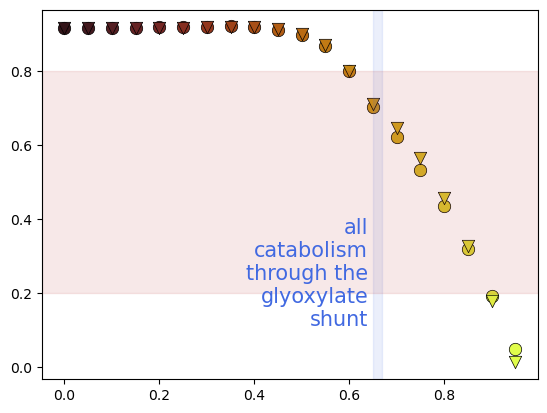

In [27]:
plt.figure()
ax = plt.subplot()
for i in np.arange(1,21):
    c = colors[i-1]
    xx = i * 0.05 - 0.05
    p1 = ax.scatter(xx, mod['summer_RQ_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest'),
                color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[i-1])

for i in np.arange(1,21):
    c = colors[i-1]
    xx = i * 0.05 - 0.05
    p1 = ax.scatter(xx, mod['summer_RQ_%i'%(i+120)].mean(dim='time').sel(zl=10, method='nearest'),
                color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='v', label=labs[i-1])

ax.axvspan(0.65,0.67, color='royalblue', alpha=0.1)
plt.text(0.64, 0.1, 'all\ncatabolism\nthrough the\nglyoxylate\nshunt', fontsize=fslab, color='royalblue',
         ha='right', va='bottom', transform=ax.transData)
ax.axhspan(0.2, 0.8, color='firebrick', alpha=0.1)


### dFe / DOC versus RQ

Text(0, 0.5, 'Respiratory quotient')

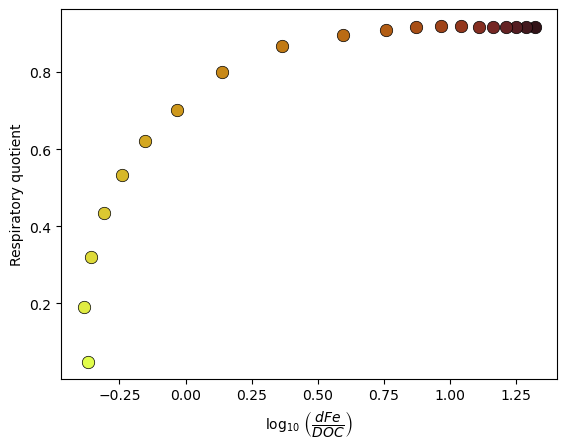

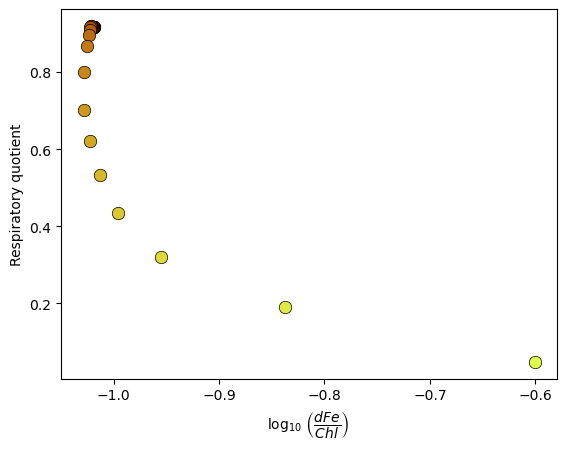

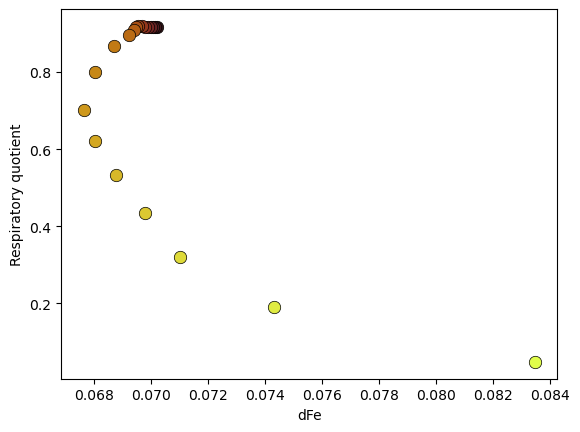

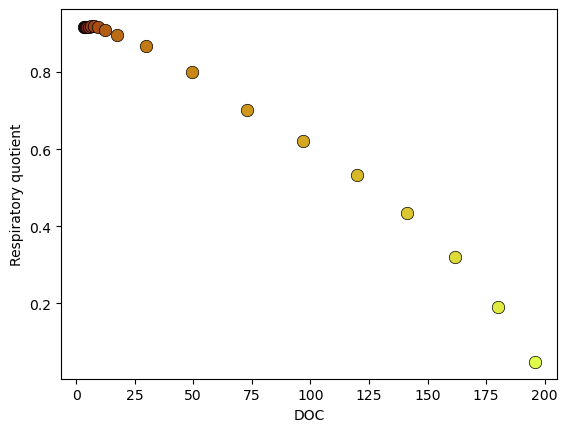

In [68]:

plt.figure()
ax = plt.subplot()
for i in np.arange(1,21):
    c = colors[i-1]
    fe = mod['summer_dfe_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest')
    doc = mod['summer_doc_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest')
    p1 = ax.scatter(np.log10(fe*1e6/doc), 
                    mod['summer_RQ_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest'),
                    color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[i-1])

ax.set_xlabel(r"log$_{10}$ $\left(\dfrac{dFe}{DOC}\right)$ ")
ax.set_ylabel("Respiratory quotient")

plt.figure()
ax = plt.subplot()
for i in np.arange(1,21):
    c = colors[i-1]
    fe = mod['summer_dfe_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest')
    chl = mod['summer_chl_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest')
    p1 = ax.scatter(np.log10(fe*1e9/(chl*1e6*12)), 
                    mod['summer_RQ_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest'),
                    color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[i-1])

ax.set_xlabel(r"log$_{10}$ $\left(\dfrac{dFe}{Chl}\right)$ ")
ax.set_ylabel("Respiratory quotient")


plt.figure()
ax = plt.subplot()
for i in np.arange(1,21):
    c = colors[i-1]
    fe = mod['summer_dfe_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest')
    p1 = ax.scatter(fe*1e9, 
                    mod['summer_RQ_%i'%(i+100)].mean(dim='time').sel(zl=10, method='nearest'),
                    color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[i-1])

ax.set_xlabel(r"dFe")
ax.set_ylabel("Respiratory quotient")

plt.figure()
ax = plt.subplot()
for i in np.arange(1,21):
    c = colors[i-1]
    doc = mod['summer_doc_%i'%(i+100)].sel(zl=slice(0,100)).mean(dim=['time','zl'])
    p1 = ax.scatter(doc*1e6, 
                    mod['summer_RQ_%i'%(i+100)].sel(zl=slice(0,100)).mean(dim=['time','zl']),
                    color=c, edgecolor='k', linewidth=lwid*0.5, s=80, marker='o', label=labs[i-1])

ax.set_xlabel("DOC")
ax.set_ylabel("Respiratory quotient")


#ax.axvspan(0.65,0.67, color='royalblue', alpha=0.1)
#plt.text(0.64, 0.1, 'all\ncatabolism\nthrough the\nglyoxylate\nshunt', fontsize=fslab, color='royalblue',
#         ha='right', va='bottom', transform=ax.transData)
#ax.axhspan(0.2, 0.8, color='firebrick', alpha=0.1)


## Figures for talk

In [100]:
exps = ['a0p0', 'a0p5', 'a0p8']

['$\\alpha$ = 0.0', '$\\alpha$ = 0.5', '$\\alpha$ = 0.8']


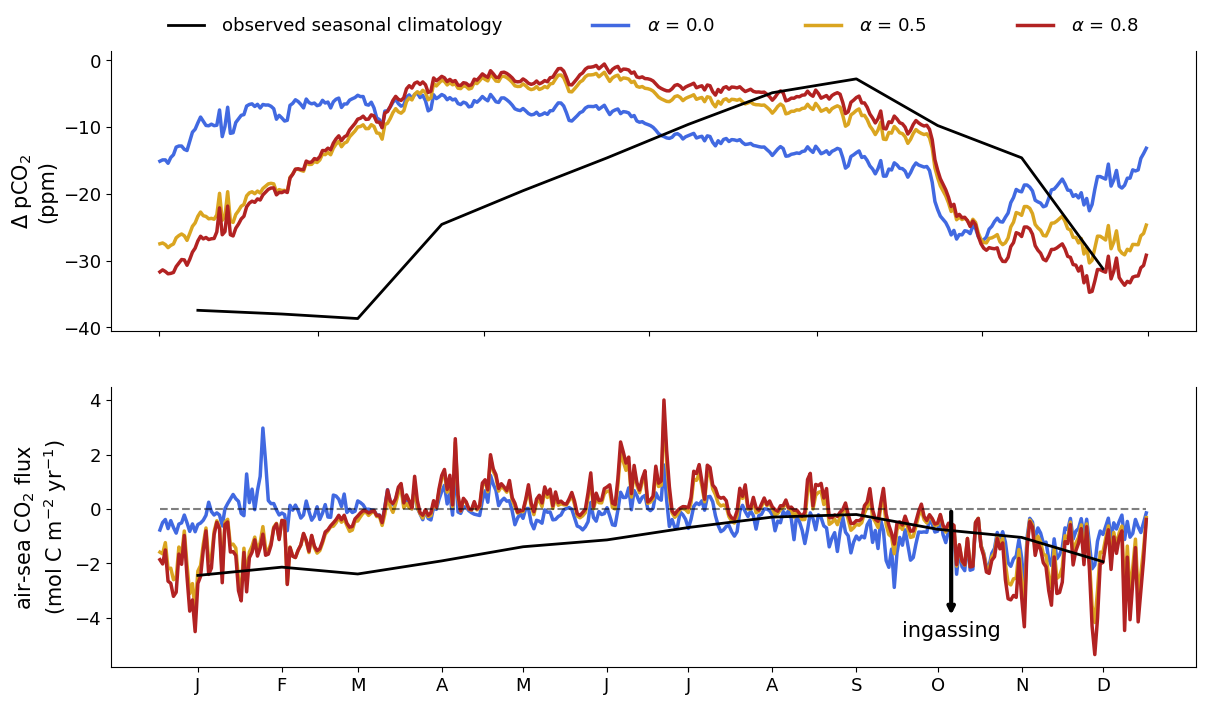

In [117]:

fstic = 13
fslab = 15
colmap = cmo.haline_r
colors = ['royalblue', 'goldenrod', 'firebrick']
lwid = 2.5
lsty = '-'
alf = 1.0

labs = []
for i,a in enumerate(np.array([0.0, 0.5, 0.8])):
    labs.append(r'$\alpha$ = %.1f'%(a))
print(labs)

fig = plt.figure(figsize=(14,8))
gs = GridSpec(2,1)

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

ax1.tick_params(labelbottom=False, labelsize=fstic)
ax2.tick_params(labelsize=fstic)

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

ax1.plot(obs_time, obs_dpco2, 'k', zorder=3, linewidth=2.0, label='observed seasonal climatology')
for i,iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax1.plot(mod_time, mod['pco2_%s'%(iv)]-395.30, color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2, label=labs[i])

ax2.plot(obs_time, obs_fgco2, color='k', zorder=3, linewidth=2.0)
ax2.plot(mod_time, mod['dic_stf_noPO'] * 0.0, 'k--', alpha=0.5, linewidth=1.5, zorder=3)
for i,iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax2.plot(mod_time, mod['dic_stf_%s'%(iv)]*86400*365*(-1), color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2)


ax2.set_xticks(obs_time, np.array(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']))

ax1.set_ylabel('$\Delta$ pCO$_2$\n(ppm)', fontsize=fslab)
ax2.set_ylabel('air-sea CO$_2$ flux\n(mol C m$^{-2}$ yr$^{-1}$)', fontsize=fslab)

t = pd.Timestamp("1909-10-20 12:00:00")
ax2.annotate(
    "",
    xy=(t, -4.0),        # arrow points here
    xytext=(t, 0.0),      # text goes here
    arrowprops=dict(arrowstyle="->", linewidth=3.0)
)

plt.text(t, -4.5, 'ingassing', fontsize=fslab, color='k',
         ha='center', va='center', transform=ax2.transData)

ax1.legend(frameon=False, ncols=4, bbox_to_anchor=(0.5,1.00), loc='lower center',
           fontsize=13, columnspacing=5, handletextpad=1)



fig.savefig("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/CO2cycle_talk.png", dpi=300, bbox_inches='tight')
fig.savefig("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/CO2cycle_talk_trans.png", dpi=300, bbox_inches='tight', transparent=True)


['$\\alpha$ = 0.0', '$\\alpha$ = 0.5', '$\\alpha$ = 0.8']


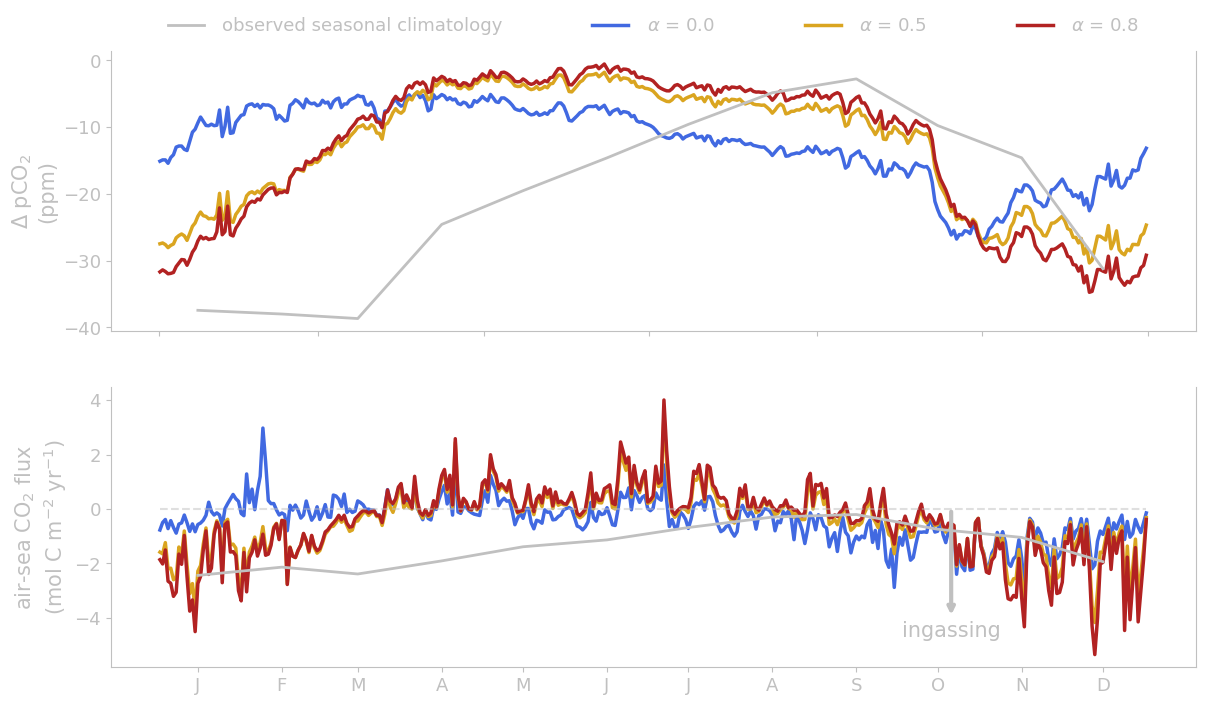

In [118]:
fstic = 13
fslab = 15
colmap = cmo.haline_r
colors = ['royalblue', 'goldenrod', 'firebrick']
lwid = 2.5
lsty = '-'
alf = 1.0

silver = 'silver'

labs = []
for i, a in enumerate(np.array([0.0, 0.5, 0.8])):
    labs.append(r'$\alpha$ = %.1f' % a)
print(labs)

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 1)

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# ------------------------------------------------------------------
# Ticks and tick labels
# ------------------------------------------------------------------
ax1.tick_params(
    labelbottom=False,
    labelsize=fstic,
    colors=silver
)

ax2.tick_params(
    labelsize=fstic,
    colors=silver
)

# ------------------------------------------------------------------
# Spines
# ------------------------------------------------------------------
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color(silver)

# ------------------------------------------------------------------
# pCO2
# ------------------------------------------------------------------
ax1.plot(
    obs_time,
    obs_dpco2,
    color=silver,
    zorder=3,
    linewidth=2.0,
    label='observed seasonal climatology'
)

for i, iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax1.plot(
        mod_time,
        mod['pco2_%s' % iv] - 395.30,
        color=c,
        linewidth=lwid,
        alpha=alf,
        linestyle=lsty,
        zorder=2,
        label=labs[i]
    )

# ------------------------------------------------------------------
# CO2 flux
# ------------------------------------------------------------------
ax2.plot(
    obs_time,
    obs_fgco2,
    color=silver,
    zorder=3,
    linewidth=2.0
)

# Zero line
ax2.plot(
    mod_time,
    mod['dic_stf_noPO'] * 0.0,
    linestyle='--',
    color=silver,
    alpha=0.5,
    linewidth=1.5,
    zorder=3
)

for i, iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax2.plot(
        mod_time,
        mod['dic_stf_%s' % iv] * 86400 * 365 * (-1),
        color=c,
        linewidth=lwid,
        alpha=alf,
        linestyle=lsty,
        zorder=2
    )

# ------------------------------------------------------------------
# X ticks
# ------------------------------------------------------------------
ax2.set_xticks(
    obs_time,
    np.array(['J', 'F', 'M', 'A', 'M', 'J',
              'J', 'A', 'S', 'O', 'N', 'D'])
)

# ------------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------------
ax1.set_ylabel(
    '$\Delta$ pCO$_2$\n(ppm)',
    fontsize=fslab,
    color=silver
)

ax2.set_ylabel(
    'air-sea CO$_2$ flux\n(mol C m$^{-2}$ yr$^{-1}$)',
    fontsize=fslab,
    color=silver
)

# ------------------------------------------------------------------
# Ingassing annotation
# ------------------------------------------------------------------
t = pd.Timestamp("1909-10-20 12:00:00")

ax2.annotate(
    "",
    xy=(t, -4.0),
    xytext=(t, 0.0),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=3.0,
        color=silver
    )
)

ax2.text(
    t,
    -4.5,
    'ingassing',
    fontsize=fslab,
    color=silver,
    ha='center',
    va='center',
    transform=ax2.transData
)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
leg = ax1.legend(
    frameon=False,
    ncols=4,
    bbox_to_anchor=(0.5, 1.00),
    loc='lower center',
    fontsize=13,
    columnspacing=5,
    handletextpad=1
)

for text in leg.get_texts():
    text.set_color(silver)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
fig.savefig(
    "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/CO2cycle_talk.png",
    dpi=300,
    bbox_inches='tight'
)

fig.savefig(
    "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/CO2cycle_talk_trans.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

['$\\alpha$ = 0.0', '$\\alpha$ = 0.5', '$\\alpha$ = 0.8']


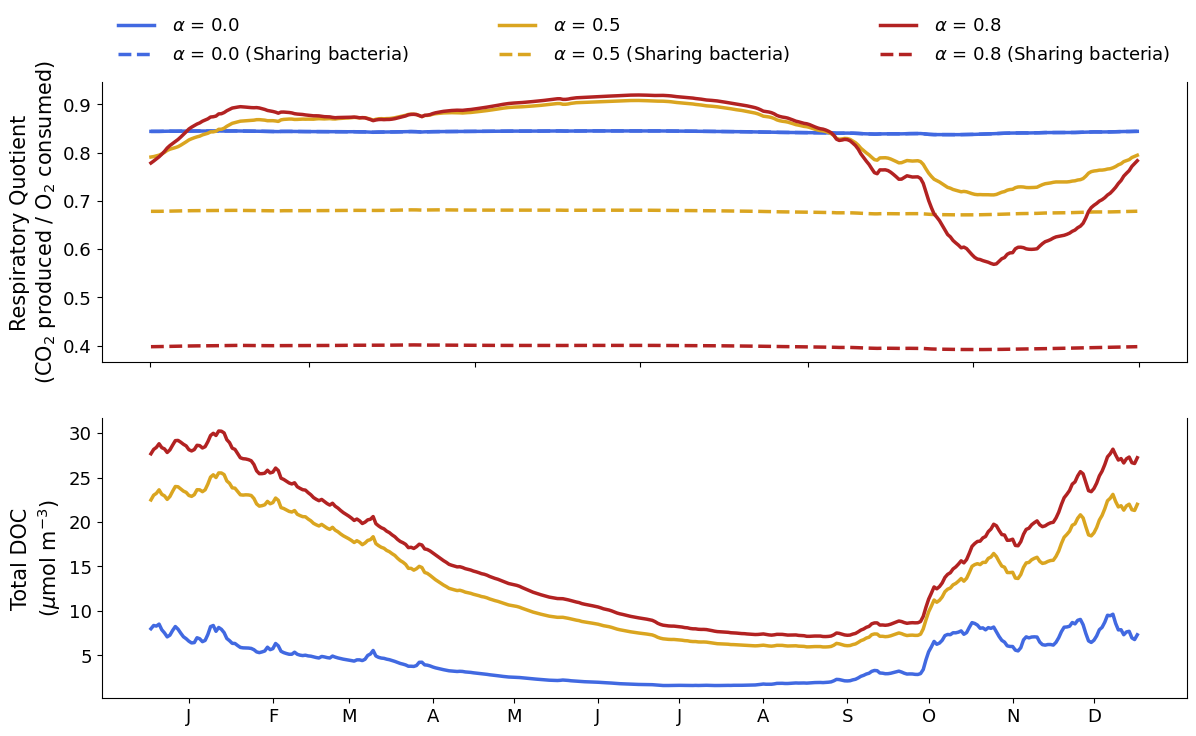

In [130]:

fstic = 13
fslab = 15
colmap = cmo.haline_r
colors = ['royalblue', 'goldenrod', 'firebrick']
lwid = 2.5
lsty = '-'
alf = 1.0

labs = []
for i,a in enumerate(np.array([0.0, 0.5, 0.8])):
    labs.append(r'$\alpha$ = %.1f'%(a))
print(labs)

fig = plt.figure(figsize=(14,8))
gs = GridSpec(2,1)

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

ax1.tick_params(labelsize=fstic, labelbottom=False)
ax2.tick_params(labelsize=fstic)

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

for i,iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax1.plot(mod_time, mod['RQ_%s'%(iv)].isel(zl=0), color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2, label=labs[i])
    ax1.plot(mod_time, mod['lbacRQ_%s'%(iv)].isel(zl=0), color=c, linewidth=lwid, alpha=alf, linestyle='--', zorder=2, label=labs[i] + " (Sharing bacteria)")

for i,iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax2.plot(mod_time, mod['doc_%s'%(iv)].isel(zl=0)*1e6*1.035, color=c, linewidth=lwid, alpha=alf, linestyle=lsty, zorder=2, label=labs[i])

ax2.set_xticks(obs_time, np.array(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']))

ax1.set_ylabel('Respiratory Quotient\n(CO$_2$ produced / O$_2$ consumed)', fontsize=fslab)
ax2.set_ylabel('Total DOC\n($\mu$mol m$^{-3}$)', fontsize=fslab)

ax1.legend(frameon=False, ncols=3, bbox_to_anchor=(0.5,1.00), loc='lower center',
           fontsize=13, columnspacing=5, handletextpad=1)


fig.savefig("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/RQ_talk.png", dpi=300, bbox_inches='tight')


['$\\alpha$ = 0.0', '$\\alpha$ = 0.5', '$\\alpha$ = 0.8']


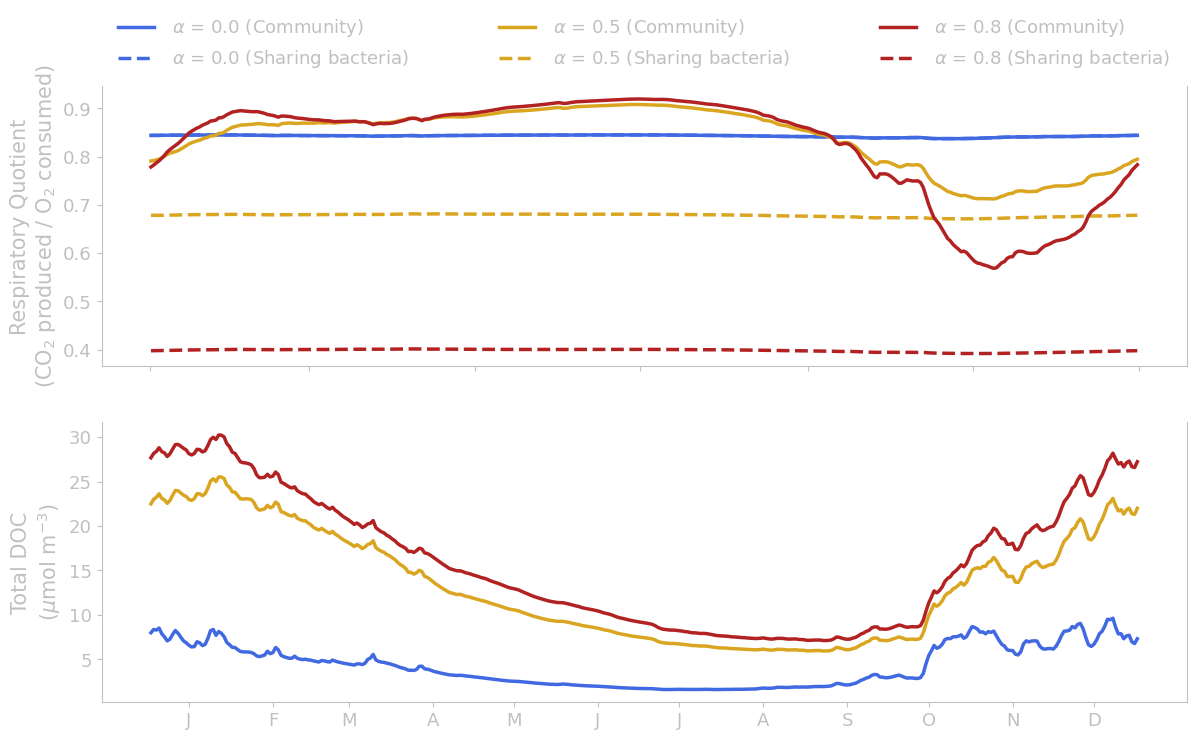

In [132]:
fstic = 13
fslab = 15
colmap = cmo.haline_r
colors = ['royalblue', 'goldenrod', 'firebrick']
lwid = 2.5
lsty = '-'
alf = 1.0

silver = 'silver'

labs = []
for i, a in enumerate(np.array([0.0, 0.5, 0.8])):
    labs.append(r'$\alpha$ = %.1f' % (a))
print(labs)

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 1)

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# ------------------------------------------------------------------
# Ticks and tick labels
# ------------------------------------------------------------------
ax1.tick_params(labelsize=fstic, labelbottom=False, colors=silver)
ax2.tick_params(labelsize=fstic, colors=silver)

# ------------------------------------------------------------------
# Spines
# ------------------------------------------------------------------
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color(silver)

# ------------------------------------------------------------------
# Plot data
# ------------------------------------------------------------------
for i, iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax1.plot(
        mod_time,
        mod['RQ_%s' % (iv)].isel(zl=0),
        color=c,
        linewidth=lwid,
        alpha=alf,
        linestyle=lsty,
        zorder=2,
        label=labs[i] + " (Community)"
    )
    ax1.plot(
        mod_time,
        mod['lbacRQ_%s' % (iv)].isel(zl=0),
        color=c,
        linewidth=lwid,
        alpha=alf,
        linestyle='--',
        zorder=2,
        label=labs[i] + " (Sharing bacteria)"
    )

for i, iv in enumerate(['a0p0', 'a0p5', 'a0p8']):
    c = colors[i]
    ax2.plot(
        mod_time,
        mod['doc_%s' % (iv)].isel(zl=0) * 1e6 * 1.035,
        color=c,
        linewidth=lwid,
        alpha=alf,
        linestyle=lsty,
        zorder=2,
        label=labs[i]
    )

# ------------------------------------------------------------------
# X ticks
# ------------------------------------------------------------------
ax2.set_xticks(
    obs_time,
    np.array(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
)

# ------------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------------
ax1.set_ylabel(
    'Respiratory Quotient\n(CO$_2$ produced / O$_2$ consumed)',
    fontsize=fslab,
    color=silver
)

ax2.set_ylabel(
    'Total DOC\n($\mu$mol m$^{-3}$)',
    fontsize=fslab,
    color=silver
)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
leg = ax1.legend(
    frameon=False,
    ncols=3,
    bbox_to_anchor=(0.5, 1.00),
    loc='lower center',
    fontsize=13,
    columnspacing=5,
    handletextpad=1
)

for text in leg.get_texts():
    text.set_color(silver)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
fig.savefig(
    "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures/RQ_talk_trans.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True
)